
<span style="color:red">**Please don't work in the original notebook in the DeYonker-lab-scripts repo! Copy to your own QM dir and use your local version**</span>

# How to use this notebook

The first time you open this notebook, you have to:
- make sure you've copied it to your QM dir and you're using that local version, **not** the original in ~/github/DeYonker-lab-scripts/dwappett
- uncomment one of the path lines in the code block below so that the notebook knows where to read your data from

Then each time you use it, all you need to do is:
- in the code block below, select the directories to read and plot the data from by setting fdir as an empty list or list of strings
    - `fdir = []` --> all results from all fxxxxx-fxxxxx directories will be plotted
    - `fdir = ['fxxxxx-fxxxxx',...]` --> only results from the given 'fxxxxx-fxxxxx' directories will be included
    - directories selected in the fdir list (if not left empty) need to contain a [dir]_results.csv file created by collect_CM_results.py otherwise you'll get errors when it tries to read the data!
- click "Run All" to update all plots with the current results from the selected directories

In [75]:
""" specify QMdir path by uncommenting one of these lines """
path = '/project/ndyonker/chem/cm-MD-processing/MD-QM/QM-A'
#path = '/project/pssntngr/chem/chorismate_mutase/QM-B'
#path = '/project/hksasi/chem/chorismate_mutase/QM-C'
#path = '/project/dwappett/chorismate_mutase/QM-batch-models'

""" specify fxxxxx-fxxxxx directory/directories to plot results from in list like ['f00101-f00200','f00201-f00300'] """
""" or leave empty to compile results for all your finished models """
#fdir = ['B256-every-100th']
fdir = []

**Note:** Most plots in this notebook are followed by a secondary code block that identifies outliers visible in the plot so that you don't have to work out how to find them yourselves.

If the outliers are labeled in the plots based on some rule that I've defined, the code block will print those frame names again in case the plot labels are hard to read. 
In some cases I haven't picked a default cutoff for outliers, so the code block just helps you filter the dataframe to identify any points that stand out to you by picking a cutoff that makes sense for your own data.

# Set up notebook environment


## import packages

In [76]:
import os, os.path, glob
import pickle
import ast
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import seaborn as sns
import tol_colors as tc
#import nglview

### anyone want to test out nglview?? :D

if you want to play around with the nglview package to look at structures within the notebook, install nglview into your rinrus conda environment like `conda install nglview -c conda-forge` and uncomment the `import nglview` line in the code block above. then throughout the notebook you can add code blocks to view structures that stand out in the plots?

starting point of how to do that from my like 5-10 mins of testing
```
pdbfile = glob.glob(f'{path}/A128-every-100th-1pct-filter/f12900/*-opt.pdb')[0]
view = nglview.show_file(pdbfile)
view.add_licorice(selection='protein')
view.add_licorice(selection='solvent')
view
```

ends of MCs seem to be rendered weird/it draws bonds between all atoms creating an ugly cluster. you'll need to work out how to fix that so you don't think stuff is wrong when it isn't :D

[nglview documentation here](https://nglviewer.org/nglview/latest/api.html)


## set default font sizes

The following block sets up some default figure widths and font sizes to make it easier to make nice consistent figures for publication. We don't have to use them from day one but I figured it's nice to already have in here for later.

fig sizes for publications:
- single column: approx 8cm wide
- double column: approx 18cm wide


In [77]:
# set default font sizes
# use 16/18/20 for publication quality figures with widths of 8 or 18
#SMALL_SIZE = 16 
#MEDIUM_SIZE = 18 
#BIGGER_SIZE = 20 

# going to be making smaller plots for initial looks otherwise the figs are huge on a big screen. so halving the font sizes to match
SMALL_SIZE = 12
MEDIUM_SIZE = 12 
BIGGER_SIZE = 16 

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# single column figure width
scolw = 8
# double column figure width
dcolw = 18

## read in data

In [78]:
# get names of results files to check
# just ones in fdir directories if list given otherwise all directories
if fdir:
    QMfiles = [glob.glob(f'{path}/{f}/*_results.csv')[0] for f in fdir]
else:
    QMfiles = glob.glob(f'{path}/*/*_results.csv')
QMfiles.sort()

# read in the data from the selected files
for f in QMfiles:
    if QMfiles.index(f)==0:
        df = pd.read_csv(f,index_col='frame')
    else:
        df = pd.concat([df,pd.read_csv(f,index_col='frame')])

# properly convert lists of imag modes from strings and make column of just max imag mode vals
# also turn nimag lists into just integer val lists and get list that's total no. of irc imag modes
for struc in ['ts','r','p']:
    imagmodes = list(df[f'{struc}_imagmodes'])
    imagmodes = [ast.literal_eval(i) for i in imagmodes]
    df[f'{struc}_imagmodes'] = imagmodes
    df[f'{struc}_maximagmode'] = [i[0] if i else np.nan for i in imagmodes]
    nimag = list(df[f'{struc}_Nimag'])
    df[f'{struc}_Nimag'] = [int(i.replace('Nimag=','')) if isinstance(i,str) else i for i in nimag]
df['tot_irc_Nimag'] = df['r_Nimag']+df['p_Nimag']

/tmp/ndyonker-tmpdir-X3BreZ/ipykernel_3516136/1494514898.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,pd.read_csv(f,index_col='frame')])


## read in FG tables and normalise residue sequence numbers

if you want labels with asterisk denoting second chain of interface, replace lines 12-13 (after `idx = int(idx) % 128`) with this:
```
        if idx in [57,58,59,60,63,73,74,75]: 
            normalised_FGs.append(f'{idx}*_{res}')
            original_FG_names[f'{idx}*_{res}'] = i
        else: 
            normalised_FGs.append(f'{idx}_{res}')
            original_FG_names[f'{idx}_{res}'] = i
```

In [79]:
# read in the model functional groups tables
if fdir:
    FGfiles = [glob.glob(f'{path}/{f}/*_model_FGs.csv')[0] for f in fdir]
else:
    FGfiles = glob.glob(f'{path}/*/*_model_FGs.csv')
FGfiles.sort()
for f in FGfiles:
    if FGfiles.index(f)==0:
        fg_df = pd.read_csv(f,index_col='frame')
    else:
        fg_df = pd.concat([fg_df,pd.read_csv(f,index_col='frame')])
fg_df = fg_df.fillna(0).astype(int)

normalised_FGs = []
original_FG_names = {}
for i in fg_df.columns:
    ch,idx,res = i.split(':')
    # leave water names as is for now
    if ch == 'W':
        normalised_FGs.append(i)
        original_FG_names[i] = i
    else:
        # % does modulo = remainder when divided by 128
        idx = int(idx) % 128
        normalised_FGs.append(f'{idx}_{res}')
        original_FG_names[f'{idx}_{res}'] = i
fg_df.columns = normalised_FGs

# add FG counts to main dataframe
df['nFG_all'] = fg_df.sum(axis=1)
df['nFG_prot'] = fg_df[[c for c in fg_df.columns if 'WAT' not in c]].sum(axis=1)
df['nFG_SC'] = fg_df[[c for c in fg_df.columns if 'SC' in c]].sum(axis=1)
df['nFG_MC'] = fg_df[[c for c in fg_df.columns if 'MC' in c]].sum(axis=1)
df['nFG_wat'] = fg_df[[c for c in fg_df.columns if 'WAT' in c]].sum(axis=1)


In [80]:
# new prot FG format: id_SC_RES or id_MC
fg_df.columns

Index(['7_SC_ARG', '78_SC_GLU', '90_SC_ARG', '108_SC_TYR', '115_SC_LEU',
       '115_MC', '57_SC_PHE', '59_SC_ALA', '59_MC', '63_SC_ARG', '73_MC',
       '74_MC', '75_SC_CYS', 'W:397:WAT', 'W:398:WAT', 'W:400:WAT',
       'W:401:WAT', 'W:404:WAT', '60_SC_LYS', '74_SC_THR', 'W:396:WAT',
       'W:402:WAT', 'W:405:WAT', 'W:395:WAT', 'W:406:WAT', 'W:407:WAT',
       'W:409:WAT', 'W:394:WAT', 'W:403:WAT', '7_MC', '8_SC_GLY', '8_MC',
       '9_SC_ALA', '9_MC', '57_MC', '58_SC_PRO', '58_MC', '73_SC_VAL',
       'W:408:WAT', 'W:399:WAT', 'W:410:WAT', 'W:411:WAT', 'W:412:WAT',
       'W:413:WAT', 'W:414:WAT', 'W:415:WAT', 'W:417:WAT', 'W:416:WAT',
       'W:419:WAT', 'W:418:WAT', 'W:420:WAT', '116_MC', '117_SC_PRO', '117_MC',
       'W:422:WAT', 'W:423:WAT', 'W:421:WAT', 'W:424:WAT', 'W:425:WAT',
       '60_MC'],
      dtype='object')

### also normalise names in hb columns

In [81]:
# make dict of residue names for reformatting hb identifiers
res_names = {}
for i in fg_df.columns:
    if 'SC' in i:
        i = i.split('_', maxsplit=1)
        res_names[int(i[0])] = i[1]

for col in ['hb_HO5_ts_fg','hb_HO5_r_fg','hb_HO5_p_fg']:
    newvals = []
    for i in df.index:
        oldval = df.loc[i,col]
        try:
            ch, idx, atom = oldval.split('/')
            idx = int(idx) % 128
            if atom in ['C','O']:
                newvals.append(f'{idx}_MC/{atom}')
            elif atom in ['N','H']:
                newvals.append(f'{idx-1}_MC/{atom}')
            else:
                newvals.append(f'{idx}_{res_names[idx]}/{atom}')
        except:
            newvals.append(oldval)
    df[col] = newvals


## define label/max/min for plotted quantities

In [82]:
# define labels, max and min values so that we can easily set axes titles/legend values and axes limits consistently in plots
# keys of this dict are the column labels from the csv file/dataframes

plotopts = {'dGa': {'longlabel': r'$\Delta G ^\ddagger$ (kcal/mol)',
                'shortlabel': r'$\Delta G ^\ddagger$',
                'max': df['dGa'].max(), 
                'min': df['dGa'].min()
                },
        'dGr': {'longlabel': r'$\Delta G _{rxn}$ (kcal/mol)',
                'shortlabel': r'$\Delta G _{rxn}$',
                'max': df['dGr'].max(), 
                'min': df['dGr'].min()
                },
        'size': {'longlabel': 'model size (no. atoms)',
                'shortlabel': 'size',
                'max': df['size'].max(), 
                'min': df['size'].min()
                },
        'charge': {'longlabel': 'overall charge',
                'shortlabel': 'charge',
                'max': df['charge'].max(), 
                'min': df['charge'].min()
                },
        'fnum': {'longlabel': 'model frame number',
                'shortlabel': 'model',
                'max': df['fnum'].max(), 
                'min': df['fnum'].min()
                },
        'nFG_all': {'longlabel': 'no. FGs in model',
                'shortlabel': 'no. FGs',
                'max': df['nFG_all'].max(), 
                'min': df['nFG_all'].min()
                },
        'nFG_prot': {'longlabel': 'no. protein FGs in model',
                'shortlabel': 'no. protein FGs',
                'max': df['nFG_prot'].max(), 
                'min': df['nFG_prot'].min()
                },
        'nFG_SC': {'longlabel': 'no. SC fragments in model',
                'shortlabel': 'no. SCs',
                'max': df['nFG_SC'].max(), 
                'min': df['nFG_SC'].min()
                },
        'nFG_MC': {'longlabel': 'no. MC fragments in model',
                'shortlabel': 'no. MCs',
                'max': df['nFG_MC'].max(), 
                'min': df['nFG_MC'].min()
                },
        'nFG_wat': {'longlabel': 'no. waters in model',
                'shortlabel': 'no. waters',
                'max': df['nFG_wat'].max(), 
                'min': df['nFG_wat'].min()
                },
        'Nhb_all': {'longlabel': 'no. H-bonds in model',
                'shortlabel': 'no. H-bonds',
                'max': df[[c for c in df.columns if 'Nhb' in c and 'all' in c]].max().max(), 
                'min': df[[c for c in df.columns if 'Nhb' in c and 'all' in c]].min().min()
                },
        'Nhb_lig': {'longlabel': 'no. H-bonds with ligand in model',
                'shortlabel': 'no. lig. H-bonds',
                'max': df[[c for c in df.columns if 'Nhb' in c and 'lig' in c]].max().max(), 
                'min': df[[c for c in df.columns if 'Nhb' in c and 'lig' in c]].min().min()
                }
        }

## start list of outliers

In [83]:
compile_outliers = {}

# Structure checks

## max dists moved during opts

plotting difference between max heavy atom movement and max hydrogen movement should hopefully help identify models where hydrogens have detached/transferred during the opts and messed up the results!

in the plot below, models are labeled if the maxmove value is >6 or the magnitude of the diff is >2
NJD: changed maxmove thresholds to 8 on 7/10/26

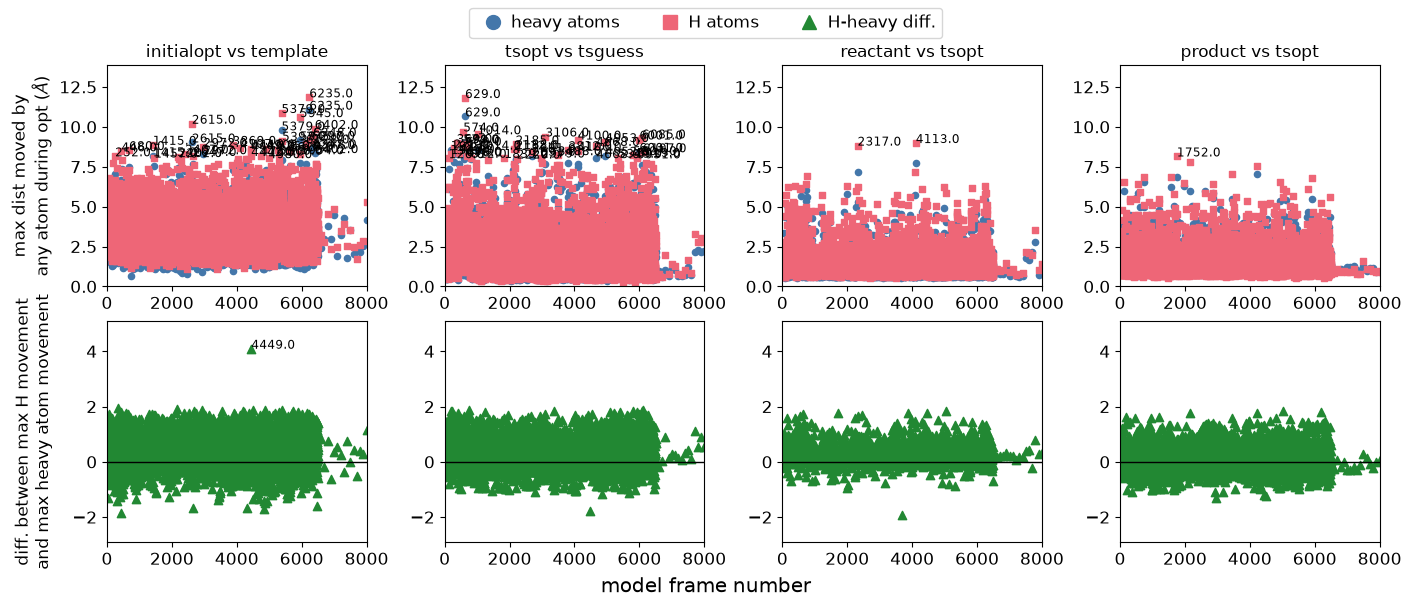

In [84]:
# get max and min of all maxmove cols so that all axes can have same limits
maxmovecols = [c for c in list(df.columns.values) if c.startswith('maxmove')]
allmin = min([np.nanmin(df[i]) for i in maxmovecols])
allmax = max([np.nanmax(df[i]) for i in maxmovecols])

# create lists of struc pairs that match the col names and clearer names for plot titles
titlelabels = ['initialopt vs template','tsopt vs tsguess','reactant vs tsopt','product vs tsopt']
pairs = ['tmp-init','guess-ts','ts-r','ts-p']

# get min and max diff also for axes limits
diffmax = max([np.nanmax(df[f'maxmove_H_{pair}']-df[f'maxmove_heavy_{pair}']) for pair in pairs])
diffmin = min([np.nanmin(df[f'maxmove_H_{pair}']-df[f'maxmove_heavy_{pair}']) for pair in pairs])

# define markers that will be used so it's easier to make one combined legend
legend_elements = [Line2D([0], [0], marker='o', ls='none', label='heavy atoms', color=tc.bright.blue, markersize=10), 
Line2D([0], [0], marker='s', ls='none', label='H atoms', color=tc.bright.red, markersize=10),
Line2D([0], [0], marker='^', ls='none', label='H-heavy diff.', color=tc.bright.green, markersize=10)]

# set up dict to collect model numbers of the outliers
outliermodels = {}
for pair in pairs:
    for t in ['H','heavy','diff']:
        outliermodels[(pair,t)] = []

fig, axs = plt.subplots(nrows=2,ncols=4,figsize=(14,6),layout='constrained')
for i,pair in enumerate(pairs):
    # top row of plots: actual values
    df.plot(x='fnum',y=f'maxmove_heavy_{pair}',kind='scatter',ax=axs[0,i],color=tc.bright.blue,marker='o',label='heavy',legend=None)
    df.plot(x='fnum',y=f'maxmove_H_{pair}',kind='scatter',ax=axs[0,i],color=tc.bright.red,marker='s', label='H',legend=None)
    axs[0,i].set_ylim(bottom=0,top=allmax+2)
    axs[0,i].set_xlim(left=plotopts['fnum']['min']-1,right=plotopts['fnum']['max']+1)
    axs[0,i].set_xlabel(None)
    axs[0,i].set_ylabel(None)
    axs[0,i].set_title(titlelabels[i])
    # bottom row of plots: differences
    axs[1,i].axhline(y=0,color='black',linewidth=1)
    axs[1,i].scatter(x=df['fnum'],y=df[f'maxmove_H_{pair}']-df[f'maxmove_heavy_{pair}'],color=tc.bright.green,marker='^')
    axs[1,i].set_ylim(bottom=diffmin-1,top=diffmax+1)
    axs[1,i].set_xlim(left=plotopts['fnum']['min']-1,right=plotopts['fnum']['max']+1)
    axs[1,i].set_xlabel(None)
    axs[1,i].set_ylabel(None)
    # label points where maxmove H/heavy are >8 (only one label per model even if both are big) and diff > 2
    for model in list(df.index.values):
        if df.loc[model,f'maxmove_H_{pair}']>8:
            axs[0,i].annotate(df.loc[model,'fnum'],(df.loc[model,'fnum'],df.loc[model,f'maxmove_H_{pair}']),size='x-small')
            outliermodels[(pair,'H')].append(model)
        if df.loc[model,f'maxmove_heavy_{pair}']>8:
            axs[0,i].annotate(df.loc[model,'fnum'],(df.loc[model,'fnum'],df.loc[model,f'maxmove_heavy_{pair}']),size='x-small')
            outliermodels[(pair,'heavy')].append(model)
        mmdiff = df.loc[model,f'maxmove_H_{pair}'] - df.loc[model,f'maxmove_heavy_{pair}']
        if mmdiff > 2 or mmdiff < -2:
            axs[1,i].annotate(df.loc[model,'fnum'],(df.loc[model,'fnum'],mmdiff),size='x-small')
            outliermodels[(pair,'diff')].append(model)

fig.legend(handles=legend_elements,loc='outside upper center',ncols=3,handletextpad=0.1,columnspacing=2)

axs[0,0].set_ylabel('max dist moved by\nany atom during opt '+r'($\AA$)')
axs[1,0].set_ylabel('diff. between max H movement\nand max heavy atom movement')
fig.supxlabel(plotopts['fnum']['longlabel'])
fig.align_labels()


In [85]:
### show outliers in case it's hard to read from plot ###
### filtering out any combinations in dict that don't have any outliers ###
{key: outliermodels[key] for key in outliermodels.keys() if outliermodels[key]}


{('tmp-init', 'H'): ['f00252',
  'f00446',
  'f00680',
  'f01415',
  'f01457',
  'f02202',
  'f02407',
  'f02615',
  'f02647',
  'f02972',
  'f03869',
  'f04107',
  'f04441',
  'f04442',
  'f04449',
  'f04740',
  'f04908',
  'f04980',
  'f05256',
  'f05300',
  'f05379',
  'f05397',
  'f05625',
  'f05945',
  'f05954',
  'f06128',
  'f06235',
  'f06297',
  'f06348',
  'f06402'],
 ('tmp-init', 'heavy'): ['f01415',
  'f02615',
  'f02972',
  'f05379',
  'f05945',
  'f06235',
  'f06297',
  'f06348',
  'f06402'],
 ('tmp-init', 'diff'): ['f04449'],
 ('guess-ts', 'H'): ['f00126',
  'f00191',
  'f00276',
  'f00369',
  'f00443',
  'f00574',
  'f00599',
  'f00629',
  'f00659',
  'f00676',
  'f00812',
  'f01014',
  'f01839',
  'f02132',
  'f02185',
  'f02188',
  'f02220',
  'f02691',
  'f02979',
  'f03106',
  'f03488',
  'f03812',
  'f04100',
  'f04106',
  'f04668',
  'f04953',
  'f05349',
  'f05807',
  'f05919',
  'f05931',
  'f06001',
  'f06085',
  'f06107'],
 ('guess-ts', 'heavy'): ['f00191',
  

In [86]:
# get just ones with differences:
for key in [i for i in outliermodels.keys() if outliermodels[i] and i[1] == 'diff']:
    for model in outliermodels[key]:
        compile_outliers[model] = 'maxmovediff'

## better check for H detachment/transfer/etc

strucs are flagged if any of the H atoms are too far away from the heavy atom they were covalently bound to in the template pdb (too far = 1.1x the bond length in the template pdb). code below isolates all models that have flags, and shows their free energies and maxmove_diffs (good to know if they're normal)

In [87]:
# show flagged rows (if there are any)
cols = ['Hdetached'] + [c for c in df.columns if 'dG' in c or 'maxmove_diff' in c]
df.loc[df['Hdetached'].notna(),cols]

,Hdetached,dGa,dGr,maxmove_diff_tmp-init,maxmove_diff_guess-ts,maxmove_diff_ts-r,maxmove_diff_ts-p,maxmove_diff_p-r,maxmove_diff_r-init
frame,,,,,,,,,
f01258,"init,ts,r,p",13.71,-12.71,-0.43,1.03,0.60,-0.11,0.13,1.47
f01621,"init,ts,r,p",13.95,-11.75,-0.15,0.71,0.06,-0.21,-0.30,0.74
f02470,"init,ts,r,p",26.14,1.69,1.52,1.32,0.89,0.33,0.73,4.82
f02665,"init,ts,r,p",17.10,-9.56,-1.67,-0.21,0.27,-0.63,-0.22,-0.20
f02972,"init,ts,r,p",21.17,-3.28,0.46,0.48,0.71,-0.19,0.64,0.46
f03517,"init,ts,r,p",14.60,-9.74,0.28,0.71,-0.16,0.73,0.81,-0.31
f03968,"init,ts,r,p",15.59,-10.84,0.45,0.03,1.56,1.48,-0.00,1.54
f04449,"init,ts,r,p",20.93,-6.83,4.10,0.59,0.47,1.34,1.38,0.63
f05401,"ts,r,p",25.52,-13.88,0.39,1.81,0.74,0.57,0.86,1.75


In [88]:
# add Hdetached to compiled outliers
for model in list(df.index.values):
    if not df.loc[model,'Hdetached']:
        if model not in compile_outliers.keys():
            compile_outliers[model] = 'Hdetached'
        else:
            compile_outliers[model] = compile_outliers[model]+',Hdetached'

## RMSDs of strucs before/after opts

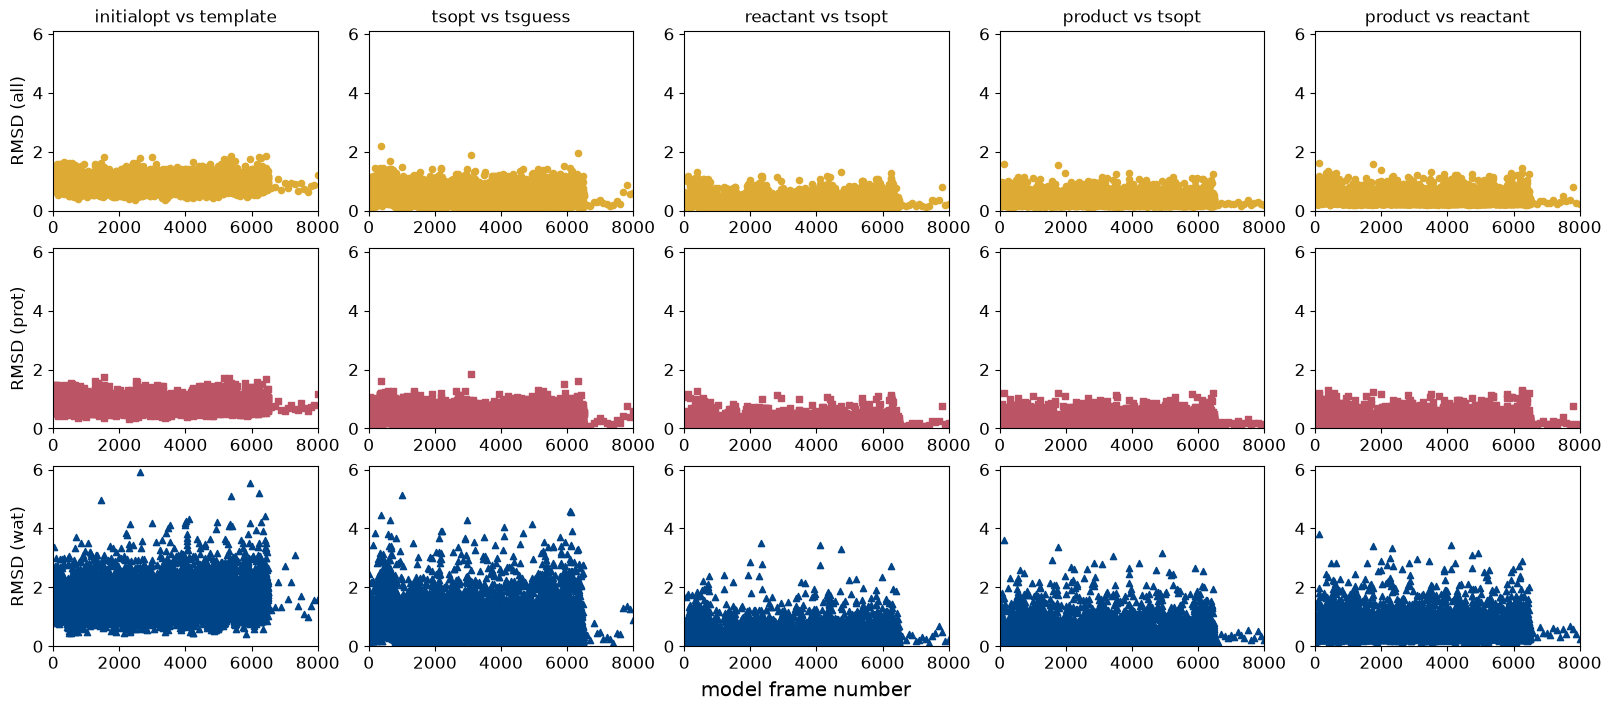

In [89]:
rmscols = [c for c in df.columns if c.startswith('rms')]
allmin = min([np.nanmin(df[i]) for i in rmscols])
allmax = max([np.nanmax(df[i]) for i in rmscols])

titlelabels = ['initialopt vs template','tsopt vs tsguess','reactant vs tsopt','product vs tsopt','product vs reactant']
pairs = ['tmp-init','guess-ts','ts-r','ts-p','p-r']
markers = ['o','s','^']
cols = [tc.high_contrast.yellow,tc.high_contrast.red,tc.high_contrast.blue]

fig, axs = plt.subplots(nrows=3,ncols=5,figsize=(16,7),layout='constrained')
for i,pair in enumerate(pairs):
    for j,rmsd in enumerate(['all','prot','wat']):
        # top row of plots: actual values
        df.plot(x='fnum',y=f'rms_{pair}_{rmsd}',kind='scatter',ax=axs[j,i],color=cols[j],marker=markers[j])
        axs[j,i].set_ylim(bottom=0,top=allmax+0.2)
        axs[j,i].set_xlim(left=plotopts['fnum']['min']-1,right=plotopts['fnum']['max']+1)
        axs[j,i].set_xlabel(None)
        axs[j,i].set_ylabel(None)
        if j==0:
            axs[j,i].set_title(titlelabels[i])
        if i==0:
            axs[j,i].set_ylabel(f'RMSD ({rmsd})')


fig.supxlabel(plotopts['fnum']['longlabel'])
fig.align_labels()



In [90]:
### quick code to filter df to find outliers ###
### change the vals of these three variables as needed ###
filt = 3.5        # set rmsd cutoff for outliers
pair = 'guess-ts'   # select pair out of ['tmp-init','guess-ts','ts-r','ts-p','p-r']
rmsd = 'wat'    # select rmsd type out of ['all','prot','wat']

df.loc[df[f'rms_{pair}_{rmsd}']>filt,f'rms_{pair}_{rmsd}']


frame
f00191    3.83
f00369    4.47
f00574    3.80
f00629    4.30
f00659    3.74
f00812    3.66
f01014    5.14
f02132    3.69
f02188    3.91
f02220    3.92
f02911    3.67
f02913    3.63
f02979    4.28
f03192    3.55
f03488    3.71
f04100    3.76
f04106    4.06
f04668    3.86
f04953    4.16
f05295    3.55
f05781    3.71
f05931    3.55
f06085    4.59
f06107    4.56
f06136    3.90
Name: rms_guess-ts_wat, dtype: float64

## water RMSDs vs number of waters
do they rearrange more when there's more of them?

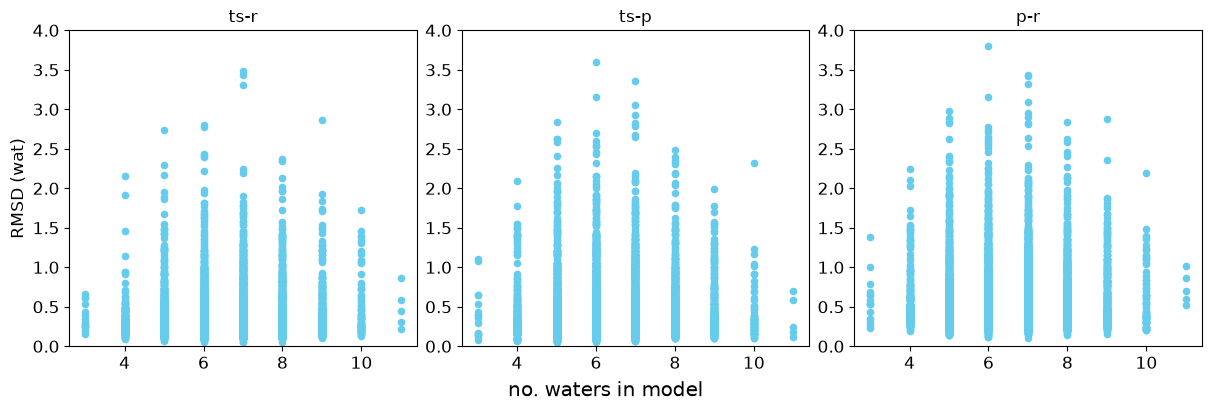

In [91]:
rmscols = ['rms_ts-r_wat','rms_ts-p_wat','rms_p-r_wat']
allmax = max([np.nanmax(df[i]) for i in rmscols])

fig, axs = plt.subplots(nrows=1,ncols=3,figsize=(12,4),layout='constrained')
for i,pair in enumerate(['ts-r','ts-p','p-r']):
    df.plot(x='nFG_wat',y=f'rms_{pair}_wat',kind='scatter',ax=axs[i],color=tc.bright.cyan)
    axs[i].set_ylim(bottom=0,top=allmax+0.2)
    axs[i].set_ylabel(None)
    axs[i].set_xlabel(None)
    axs[i].set_title(pair)
axs[0].set_ylabel('RMSD (wat)')

fig.supxlabel(plotopts['nFG_wat']['longlabel'])
fig.align_labels()



## ligand C1-C9 and C5-O7 bond distances

should be a bond between C5 and O7 in reactant and a bond between C1 and C9 in product. distances should be similar in ts.

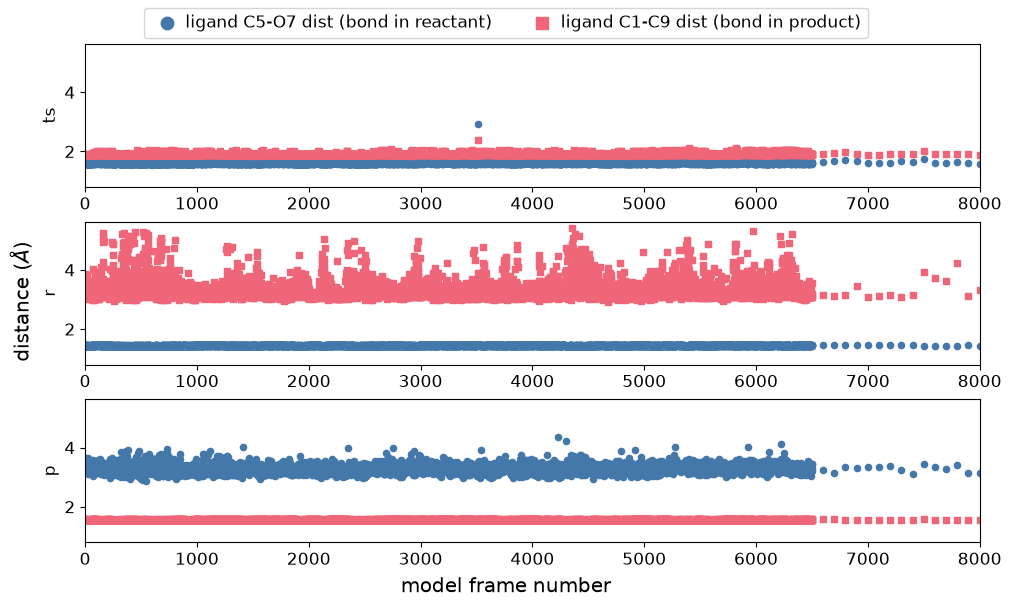

In [92]:
allmin = min([np.nanmin(df[i]) for i in ['ts_C5-O7_dist','r_C5-O7_dist','p_C5-O7_dist','ts_C1-C9_dist','r_C1-C9_dist','p_C1-C9_dist']])
allmax = max([np.nanmax(df[i]) for i in ['ts_C5-O7_dist','r_C5-O7_dist','p_C5-O7_dist','ts_C1-C9_dist','r_C1-C9_dist','p_C1-C9_dist']])

fig, axs = plt.subplots(nrows=3,ncols=1,figsize=(10,6),layout='constrained')
for i, ydata in enumerate(['ts','r','p']):
    df.plot(x='fnum',y=f'{ydata}_C5-O7_dist',kind='scatter',ax=axs[i],color=tc.bright.blue,marker='o',label='ligand C5-O7 dist (bond in reactant)')
    df.plot(x='fnum',y=f'{ydata}_C1-C9_dist',kind='scatter',ax=axs[i],color=tc.bright.red,marker='s',label='ligand C1-C9 dist (bond in product)')
    axs[i].set_ylim(bottom=0.8,top=allmax+0.2)
    axs[i].set_xlim(left=plotopts['fnum']['min']-1,right=plotopts['fnum']['max']+1)
    axs[i].set_xlabel(None)
    axs[i].set_ylabel(ydata)
    axs[i].get_legend().remove()

fig.legend(['ligand C5-O7 dist (bond in reactant)','ligand C1-C9 dist (bond in product)'],ncols=2,loc='outside upper center',markerscale=2,handletextpad=0.1,columnspacing=2)
fig.supylabel(r'distance ($\AA$)')
fig.supxlabel(plotopts['fnum']['longlabel'])
fig.align_labels()

In [93]:
### quick code to filter df to find outliers ###
### change the vals of these three variables as needed ###
filt = 5        # set distance cutoff to determine what to show
struc = 'r'     # 'ts' or 'r' or 'p'
bond = 'C1-C9'  # 'C5-O7' or 'C1-C9'

df.loc[df[f'{struc}_{bond}_dist']>filt,f'{struc}_{bond}_dist']

frame
f00159    5.26
f00161    5.10
f00328    5.21
f00349    5.24
f00397    5.13
f00406    5.01
f00425    5.15
f00447    5.27
f00517    5.27
f00529    5.16
f00545    5.26
f00566    5.03
f00567    5.17
f00676    5.06
f00683    5.07
f02140    5.05
f04356    5.43
f04366    5.07
f04381    5.23
f04419    5.14
f05975    5.32
f06218    5.15
f06321    5.22
Name: r_C1-C9_dist, dtype: float64

In [94]:
for i in df.index.values:
    # if any of the bonds are too long/short
    # NJD: adding to reactant changes to C1-C9 with threshold of 5.0 for QM-A to add missing outliers 7/10/26
    if df.loc[i,'ts_C5-O7_dist'] > 2 or df.loc[i,'ts_C1-C9_dist'] > 2.1 or df.loc[i,'r_C5-O7_dist'] > 2 or df.loc[i,'r_C1-C9_dist'] < 2.5 or df.loc[i,'p_C5-O7_dist'] < 2.5 or df.loc[i,'p_C1-C9_dist'] > 2 or df.loc[i,'r_C1-C9_dist'] > 5:
        if i not in compile_outliers.keys():
            compile_outliers[i] = 'ligdist'
        elif 'ligdist' not in compile_outliers[i]:
            compile_outliers[i] = compile_outliers[i]+',ligdist'


## ligand dihedrals around the p/r bonds

if conformation of ligand is similar to ts, dihedral should be around 0. big values indicate that the reactant/product is twisting around the relevant bond into an alternative shape?

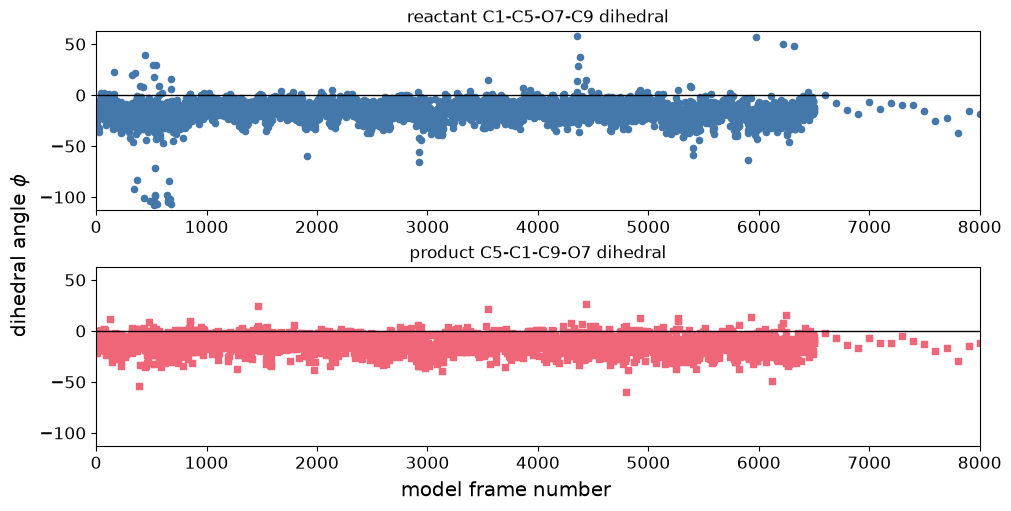

In [95]:
allmin = min([np.nanmin(df[i]) for i in ['r_C1-C5-O7-C9_dihedral','p_C5-C1-C9-O7_dihedral']])
allmax = max([np.nanmax(df[i]) for i in ['r_C1-C5-O7-C9_dihedral','p_C5-C1-C9-O7_dihedral']])

fig, axs = plt.subplots(nrows=2,ncols=1,figsize=(10,5),layout='constrained')
df.plot(x='fnum',y='r_C1-C5-O7-C9_dihedral',kind='scatter',ax=axs[0],color=tc.bright.blue,marker='o')
axs[0].set_title('reactant C1-C5-O7-C9 dihedral')
df.plot(x='fnum',y='p_C5-C1-C9-O7_dihedral',kind='scatter',ax=axs[1],color=tc.bright.red,marker='s')
axs[1].set_title('product C5-C1-C9-O7 dihedral')

for i in [0,1]:
    axs[i].set_ylim(bottom=allmin-5,top=allmax+5)
    axs[i].set_xlim(left=plotopts['fnum']['min']-1,right=plotopts['fnum']['max']+1)
    axs[i].set_xlabel(None)
    axs[i].set_ylabel(None)
    axs[i].axhline(y=0,color='black',linewidth=1)

fig.supylabel(r'dihedral angle $\phi$')
fig.supxlabel(plotopts['fnum']['longlabel'])
fig.align_labels()

In [96]:
### quick code to filter df to find outliers ###
### change the vals of these two variables as needed ###
filt = 50                           # set cutoff to determine what to show, checks +/- so just give positive val
dihed = 'r_C1-C5-O7-C9_dihedral'    # 'r_C1-C5-O7-C9_dihedral' or 'p_C5-C1-C9-O7_dihedral'

df.loc[(df[dihed]>filt)|(df[dihed]<-filt),dihed]

frame
f00340    -92.39
f00374    -82.91
f00432   -100.73
f00491   -103.59
f00526   -108.11
f00527   -103.37
f00530    -98.33
f00533    -99.08
f00535    -71.98
f00551   -106.67
f00645    -98.00
f00653   -104.54
f00654   -102.85
f00662    -84.24
f00666   -101.57
f00679   -106.89
f01906    -59.46
f02921    -55.62
f02926    -65.51
f04356     58.16
f05401    -58.70
f05403    -52.01
f05906    -63.69
f05975     57.34
f06218     50.07
Name: r_C1-C5-O7-C9_dihedral, dtype: float64

In [97]:
for i in df.index.values:
    # if any of the dihedrals have magnitude > 50
    if df.loc[i,'r_C1-C5-O7-C9_dihedral'] > 50 or df.loc[i,'r_C1-C5-O7-C9_dihedral'] < -50 or df.loc[i,'p_C5-C1-C9-O7_dihedral'] > 50 or df.loc[i,'p_C5-C1-C9-O7_dihedral'] < -50:
        if i in compile_outliers.keys():
            compile_outliers[i] = compile_outliers[i]+',dihedral'
        else:
            compile_outliers[i] = 'dihedral'


# Imaginary mode checks

## ts imaginary mode

Text(0, 0.5, 'TS imaginary mode ($cm^{-1}$)')

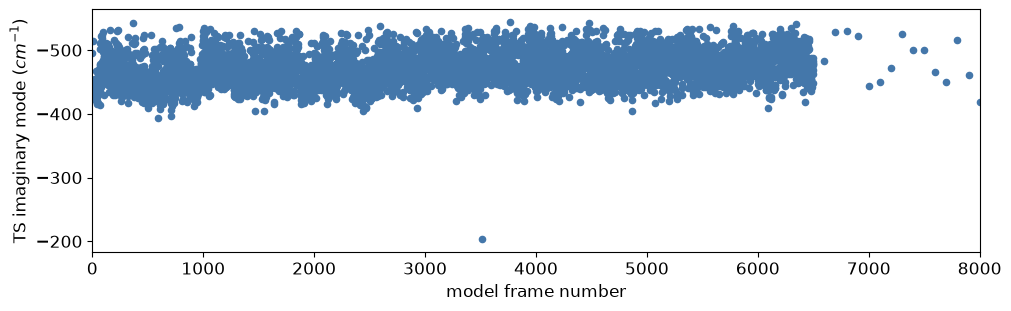

In [98]:
fig, axs = plt.subplots(nrows=1,ncols=1,figsize=(10,3),layout='constrained')
df.plot(x='fnum',y='ts_maximagmode',kind='scatter',ax=axs,color=tc.bright.blue,marker='o')
axs.set_ylim(top=np.nanmin(df['ts_maximagmode'])-20,bottom=np.nanmax(df['ts_maximagmode'])+20)
axs.set_xlim(left=plotopts['fnum']['min']-1,right=plotopts['fnum']['max']+1)
axs.set_xlabel(plotopts['fnum']['longlabel'])
axs.set_ylabel(r'TS imaginary mode ($cm^{-1}$)')


In [99]:
### quick code to filter df to find outliers ###
### change the vals of the filt variable as needed ###
filt = -300     # set cutoff to determine what to show

df.loc[df['ts_maximagmode']>filt,'ts_maximagmode']

frame
f03517   -203.17
Name: ts_maximagmode, dtype: float64

In [100]:
for i in df.index.values:
    # if any of the imag modes are not between 350 and 600
    if df.loc[i,'ts_maximagmode'] < -600 or df.loc[i,'ts_maximagmode'] > -350:
        if i in compile_outliers.keys():
            compile_outliers[i] = compile_outliers[i]+',tsmode'
        else:
            compile_outliers[i] = 'tsmode'

## irc imaginary modes

In [101]:
df['r_maximagmode'].count()

np.int64(91)

<Axes: xlabel='fnum', ylabel='p_maximagmode'>

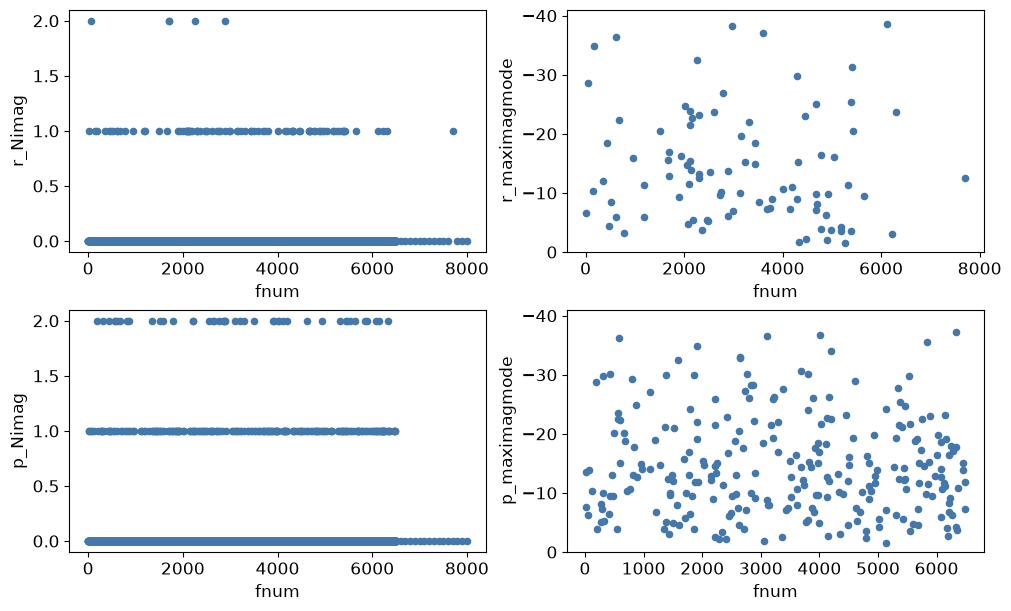

In [102]:
fig, axs = plt.subplots(nrows=2,ncols=2,figsize=(10,6),layout='constrained')
df.plot(ax=axs[0,0],x='fnum',y='r_Nimag',kind='scatter',color=tc.bright.blue,marker='o',ylim=(-0.1,2.1))
df.plot(ax=axs[1,0],x='fnum',y='p_Nimag',kind='scatter',color=tc.bright.blue,marker='o',ylim=(-0.1,2.1))
df.plot(ax=axs[0,1],x='fnum',y='r_maximagmode',kind='scatter',color=tc.bright.blue,marker='o',ylim=(0,-41))
df.plot(ax=axs[1,1],x='fnum',y='p_maximagmode',kind='scatter',color=tc.bright.blue,marker='o',ylim=(0,-41))

# Model contents

## model sizes, charges, number of fragments (all/SC/MC/wat)

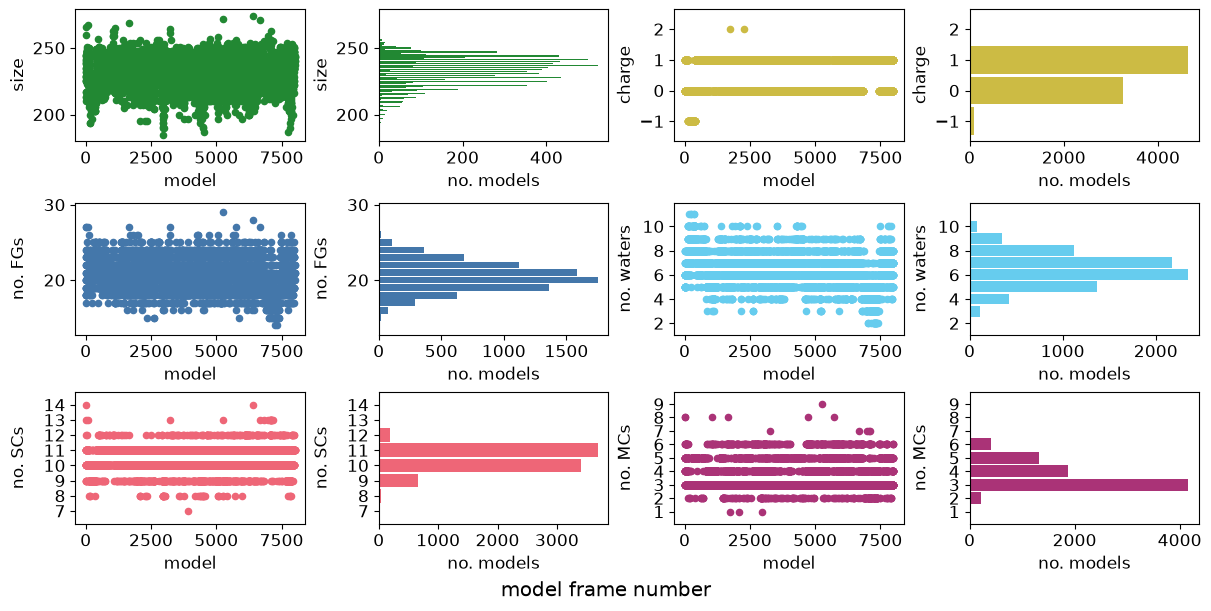

In [103]:
colours = [tc.bright.green,tc.bright.yellow,tc.bright.blue,tc.bright.cyan,tc.bright.red,tc.bright.purple]
#[tc.bright.green,tc.medium_contrast.dark_blue,tc.bright.yellow,tc.medium_contrast.dark_red]
markers = ['s','o','d','^']

fig, axs = plt.subplots(nrows=3,ncols=4,figsize=(12,6),layout='constrained')
axs = axs.reshape(-1)
for i, ydata in enumerate(['size','charge','nFG_all','nFG_wat','nFG_SC','nFG_MC']):
    df.plot(x='fnum',y=ydata,kind='scatter',ax=axs[2*i],color=colours[i],marker='o')
    axs[2*i].set_xlabel(plotopts['fnum']['shortlabel'])
    axs[2*i].set_ylabel(plotopts[ydata]['shortlabel'])
    binrange = np.arange(np.floor(plotopts[ydata]['min'])-0.5, np.ceil(plotopts[ydata]['max'])+1.5,1)
    df.hist(column=ydata,
            ax=axs[2*i+1],
            bins=binrange,
            rwidth=0.9,
            legend=False, 
            grid=False,
            color=colours[i],
            orientation='horizontal')
    axs[2*i+1].set_ylabel(plotopts[ydata]['shortlabel'])
    axs[2*i+1].set_xlabel('no. models')
    axs[2*i+1].set_title(None)
    # make y axis only show integer ticks (skipping size/no.FGs because doing this makes too many yticks and they already only show )
    if ydata not in ['size','nFG_all']:
        axs[2*i].yaxis.set_major_locator(MaxNLocator(integer=True))
        axs[2*i+1].yaxis.set_major_locator(MaxNLocator(integer=True))
    #make scatter ylims match histogram ylims
    axs[2*i].set_ylim(axs[2*i+1].get_ylim())


fig.supxlabel(plotopts['fnum']['longlabel'])
fig.align_labels()


# Free energy results

## free energy summary stats

In [104]:
# define std as std with ddof=0 so it's not using ddof=1 unintentionally
def std(x):
    return x.std(ddof=0)

# get stats across models that are done, round to 1 dp, T to transpose/flip orientation
df.loc[df['done']=='Y',['dGa','dGr']].apply(['count','median','mean',std,'min','max','ptp']).round(1).T

,count,median,mean,std,min,max,ptp
dGa,6259.0,15.1,15.5,2.1,11.2,36.3,25.0
dGr,6259.0,-10.3,-10.4,2.7,-31.5,9.3,40.8


In [105]:
# group rows by one column's value and then get stats for each group
df[['nFG_wat','dGa','dGr']].groupby("nFG_wat").agg(['count','median','mean',std,'min','max']).round(1)

dGa                                 dGr                             
        count median  mean  std   min   max count median  mean  std   min  max
nFG_wat                                                                       
2           0    NaN   NaN  NaN   NaN   NaN     0    NaN   NaN  NaN   NaN  NaN
3          16   15.0  15.5  1.5  14.2  20.0    16  -11.1 -10.6  2.2 -13.1 -2.8
4         202   14.8  14.9  1.1  12.2  21.0   202  -10.7 -11.0  1.9 -22.0 -5.6
5         992   14.8  15.1  1.5  11.2  23.4   992  -10.5 -10.8  2.2 -25.8 -1.9
6        1904   14.9  15.3  1.8  12.0  36.3  1904  -10.5 -10.7  2.5 -28.5  9.3
7        1816   15.1  15.6  2.2  11.9  34.4  1816  -10.3 -10.3  2.8 -31.5  9.2
8         943   15.4  16.0  2.4  12.0  32.1   943  -10.0  -9.9  2.8 -25.0  7.8
9         309   15.9  16.7  2.8  12.4  31.4   309   -9.1  -9.0  3.2 -26.1  3.9
10         72   16.3  16.6  2.0  13.4  22.6    72   -9.0  -8.9  2.4 -15.0 -0.9
11          5   14.8  16.7  2.5  14.6  20.5     5   -9.2  -8.8  1.7 -11.2 -6.4

In [106]:
### save vals as variables for printing later ###
dGa_mean_std = f'{df["dGa"].mean().round(1)} ± {df["dGa"].std(ddof=0).round(1)}'
dGr_mean_std = f'{df["dGr"].mean().round(1)} ± {df["dGr"].std(ddof=0).round(1)}'

## free energies vs fnum/size/charge

Text(0.5, 0.98, 'mean $\\Delta G ^\\ddagger$ = 15.5 ± 2.1 kcal/mol; mean $\\Delta G _{rxn}$ = -10.4 ± 2.7 kcal/mol')

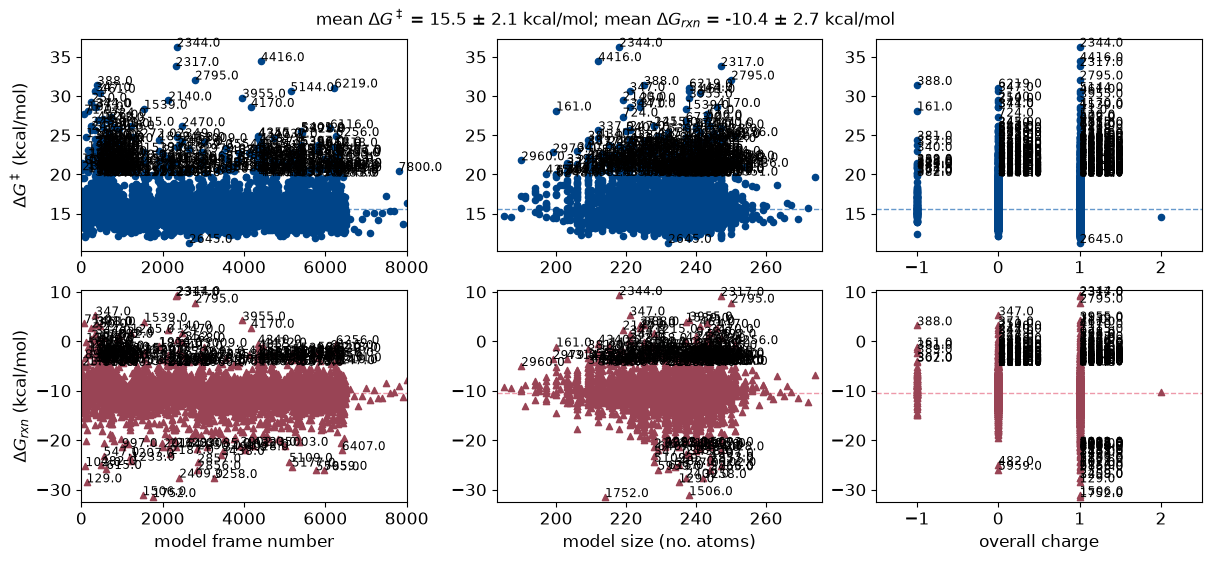

In [107]:
colours = [tc.medium_contrast.dark_blue,tc.medium_contrast.dark_red]
cols2 = [tc.medium_contrast.light_blue,tc.medium_contrast.light_red]
markers = ['o','^']

#NJD: changing to filter out more large negative reaction energies that are probably not outliers
ci_act = [df['dGa'].mean()-2*df['dGa'].std(ddof=0),df['dGa'].mean()+2*df['dGa'].std(ddof=0)]
ci_rxn = [df['dGr'].mean()-4*df['dGr'].std(ddof=0),df['dGr'].mean()+2*df['dGr'].std(ddof=0)]
outliermodels = {'dGa': [], 'dGr': []}

fig, axs = plt.subplots(nrows=2,ncols=3,figsize=(12,5.5),layout='constrained')

for i, ydata in enumerate(['dGa','dGr']):
    for j, xdata in enumerate(['fnum','size','charge']):
        axs[i,j].axhline(y=df[ydata].mean(),color=cols2[i],linestyle='--',linewidth=1,zorder=0)
        df.plot(x=xdata,y=ydata,kind='scatter',ax=axs[i,j],color=colours[i],marker=markers[i])
        axs[i,j].set_ylim(bottom=plotopts[ydata]['min']-1,top=plotopts[ydata]['max']+1)
        axs[i,j].set_xlabel(None)
        axs[i,j].set_ylabel(None)
        if xdata == 'charge':
            axs[i,j].xaxis.set_major_locator(MaxNLocator(integer=True))
            axs[i,j].set_xlim(left=plotopts[xdata]['min']-0.5,right=plotopts[xdata]['max']+0.5)
        else:
            axs[i,j].set_xlim(left=plotopts[xdata]['min']-2,right=plotopts[xdata]['max']+2)
        # add labels to outliers
        if ydata == 'dGa':
            for model in df.index.values:
                if df.loc[model,'dGa'] < ci_act[0] or df.loc[model,'dGa'] > ci_act[1]:
                    axs[i,j].annotate(df.loc[model,'fnum'],(df.loc[model,xdata],df.loc[model,'dGa']),size='x-small')
                    outliermodels['dGa'].append(model)
        elif ydata == 'dGr':
            for model in df.index.values:
                if df.loc[model,'dGr'] < ci_rxn[0] or df.loc[model,'dGr'] > ci_rxn[1]:
                    axs[i,j].annotate(df.loc[model,'fnum'],(df.loc[model,xdata],df.loc[model,'dGr']),size='x-small')
                    outliermodels['dGr'].append(model)
        if i==1:
            axs[i,j].set_xlabel(plotopts[xdata]['longlabel'])


axs[0,0].set_ylabel(plotopts['dGa']['longlabel'])
axs[1,0].set_ylabel(plotopts['dGr']['longlabel'])

fig.align_labels()
fig.suptitle(f'mean {plotopts["dGa"]["shortlabel"]} = {dGa_mean_std} kcal/mol; mean {plotopts["dGr"]["shortlabel"]} = {dGr_mean_std} kcal/mol',size=MEDIUM_SIZE)


In [108]:
### show outliers in case it's hard to read from plot ###
# converting dict contents list>set>list removes duplicates
outliermodels = {key: list(set(outliermodels[key])) for key in outliermodels.keys()}
outliermodels

{'dGa': ['f05583',
  'f04316',
  'f03747',
  'f00367',
  'f01533',
  'f02468',
  'f00567',
  'f00676',
  'f05144',
  'f05397',
  'f05598',
  'f04423',
  'f01215',
  'f04455',
  'f06297',
  'f02960',
  'f05191',
  'f03761',
  'f05343',
  'f00478',
  'f00253',
  'f04449',
  'f06124',
  'f01193',
  'f02656',
  'f00374',
  'f00402',
  'f04358',
  'f01316',
  'f00674',
  'f00397',
  'f01732',
  'f06116',
  'f06231',
  'f00574',
  'f00529',
  'f03955',
  'f01906',
  'f00523',
  'f04480',
  'f00172',
  'f01556',
  'f00384',
  'f03359',
  'f01018',
  'f00805',
  'f00390',
  'f00566',
  'f02972',
  'f00536',
  'f03009',
  'f05345',
  'f04371',
  'f00479',
  'f01162',
  'f03866',
  'f01536',
  'f04229',
  'f00436',
  'f00666',
  'f04356',
  'f06115',
  'f02645',
  'f00537',
  'f00350',
  'f06265',
  'f00417',
  'f00450',
  'f02979',
  'f04381',
  'f02250',
  'f05272',
  'f00023',
  'f00344',
  'f05354',
  'f05159',
  'f05067',
  'f00924',
  'f00559',
  'f02407',
  'f02965',
  'f05379',
  'f03528

In [109]:
for j in ['dGa','dGr']:
    for i in outliermodels[j]:
        if i in compile_outliers.keys():
            compile_outliers[i] = compile_outliers[i]+f',{j}'
        else:
            compile_outliers[i] = j

## free energies vs no. fragments

outliers are labeled in plots above so not repeating them here

Text(0.5, 0.98, 'mean $\\Delta G ^\\ddagger$ = 15.5 ± 2.1 kcal/mol; mean $\\Delta G _{rxn}$ = -10.4 ± 2.7 kcal/mol')

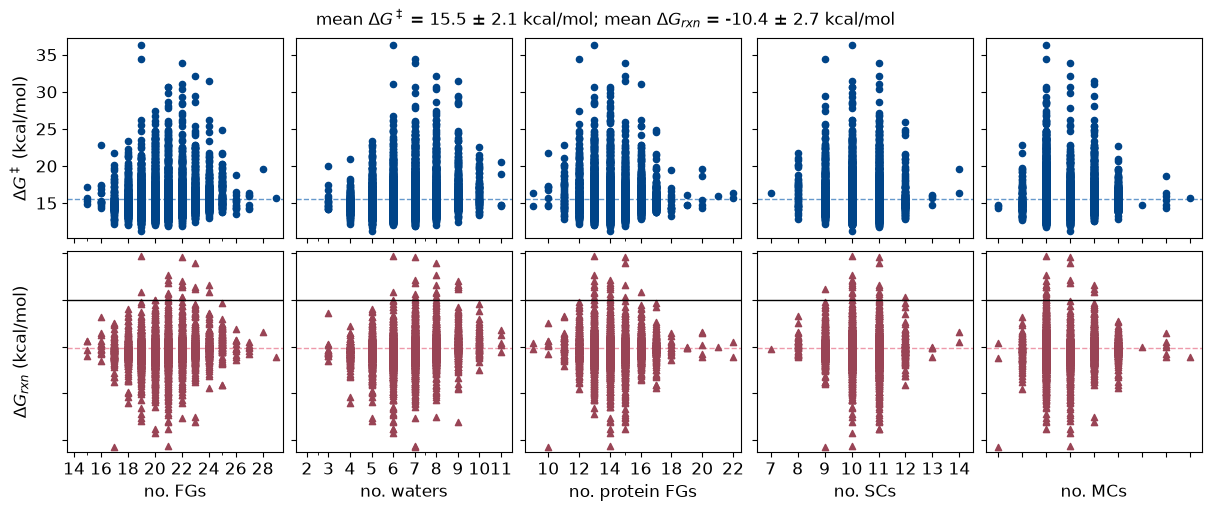

In [110]:
colours = [tc.medium_contrast.dark_blue,tc.medium_contrast.dark_red]
cols2 = [tc.medium_contrast.light_blue,tc.medium_contrast.light_red]
markers = ['o','^']

fig, axs = plt.subplots(nrows=2,ncols=5,figsize=(12,5),layout='constrained')

for i, ydata in enumerate(['dGa','dGr']):
    for j, xdata in enumerate(['nFG_all','nFG_wat','nFG_prot','nFG_SC','nFG_MC']):
        axs[i,j].axhline(y=0,color='black',linewidth=1)
        axs[i,j].axhline(y=df[ydata].mean(),color=cols2[i],linestyle='--',linewidth=1,zorder=0)
        df.plot(x=xdata,y=ydata,kind='scatter',ax=axs[i,j],color=colours[i],marker=markers[i])
        if j==0:
            axs[i,j].set_ylim(bottom=plotopts[ydata]['min']-1,top=plotopts[ydata]['max']+1)
        else:
            axs[i,j].sharey(axs[i,0])
        axs[i,j].set_xlabel(None)
        axs[i,j].set_ylabel(None)
        axs[i,j].xaxis.set_major_locator(MaxNLocator(integer=True))
        axs[i,j].set_xlim(left=plotopts[xdata]['min']-0.5,right=plotopts[xdata]['max']+0.5)
        if i==1:
            axs[i,j].set_xlabel(plotopts[xdata]['shortlabel'])
            axs[0,j].sharex(axs[1,j])

# I dunno why sharing the axes doesn't remove the tick labels from all subplots but some have to be manually fixed up
axs[1,4].set_yticklabels([])
axs[0,4].set_xticklabels([])

axs[0,0].set_ylabel(plotopts['dGa']['longlabel'])
axs[1,0].set_ylabel(plotopts['dGr']['longlabel'])

fig.align_labels()
fig.suptitle(f'mean {plotopts["dGa"]["shortlabel"]} = {dGa_mean_std} kcal/mol; mean {plotopts["dGr"]["shortlabel"]} = {dGr_mean_std} kcal/mol',size=MEDIUM_SIZE)


## free energies coloured by ts-r and p-r RMSDs

Text(0.5, 0.98, 'mean $\\Delta G ^\\ddagger$ = 15.5 ± 2.1 kcal/mol; mean $\\Delta G _{rxn}$ = -10.4 ± 2.7 kcal/mol')

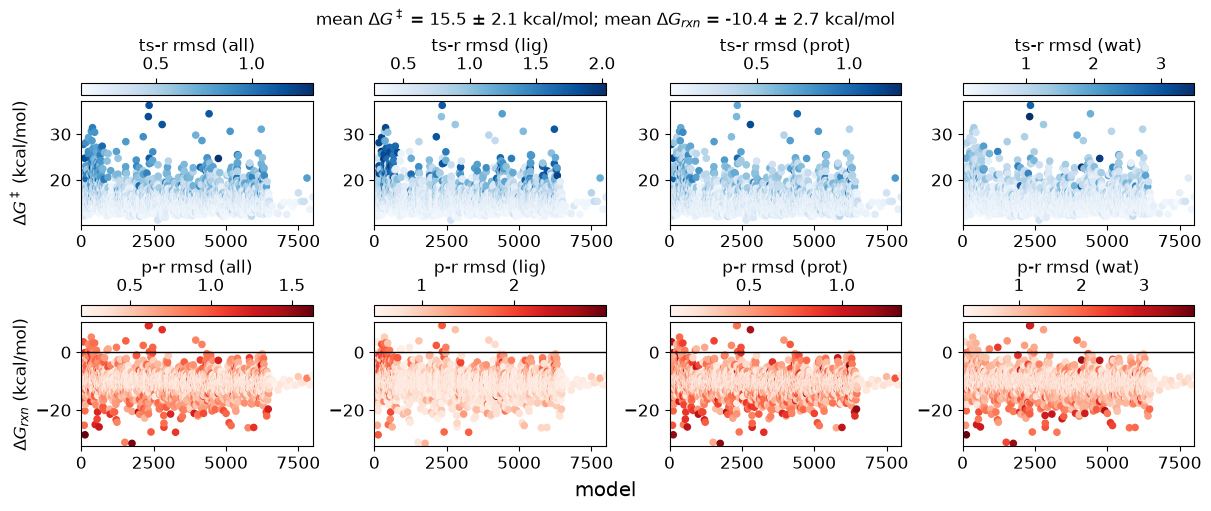

In [111]:
fig, axs = plt.subplots(nrows=2,ncols=4,figsize=(12,5),layout='constrained')

for i, rmstype in enumerate(['all','lig','prot','wat']):
    axs[0,i].axhline(y=0,color='black',linewidth=1)
    axs[1,i].axhline(y=0,color='black',linewidth=1)
    p1 = df.plot.scatter(x='fnum',y='dGa',ax=axs[0,i],c=f'rms_ts-r_{rmstype}',cmap='Blues',colorbar=False,ylim=(plotopts['dGa']['min']-1,plotopts['dGa']['max']+1),xlim=(plotopts['fnum']['min']-1,plotopts['fnum']['max']+1))
    p2 = df.plot.scatter(x='fnum',y='dGr',ax=axs[1,i],c=f'rms_p-r_{rmstype}',cmap='Reds',colorbar=False,ylim=(plotopts['dGr']['min']-1,plotopts['dGr']['max']+1),xlim=(plotopts['fnum']['min']-1,plotopts['fnum']['max']+1))
    cbar1 = plt.colorbar(p1.collections[0], ax=axs[0,i], location='top', orientation='horizontal',label=f'ts-r rmsd ({rmstype})')
    cbar2 = plt.colorbar(p2.collections[0], ax=axs[1,i], location='top', orientation='horizontal',label=f'p-r rmsd ({rmstype})')
    axs[0,i].set_ylabel(None)
    axs[1,i].set_ylabel(None)
    axs[0,i].set_xlabel(None)
    axs[1,i].set_xlabel(None)
    
axs[0,0].set_ylabel(plotopts['dGa']['longlabel'])
axs[1,0].set_ylabel(plotopts['dGr']['longlabel'])
fig.supxlabel('model')

fig.align_labels()
fig.suptitle(f'mean {plotopts["dGa"]["shortlabel"]} = {dGa_mean_std} kcal/mol; mean {plotopts["dGr"]["shortlabel"]} = {dGr_mean_std} kcal/mol',size=MEDIUM_SIZE)


## free energies coloured to show ircs with imag modes

Text(0.5, 0.98, 'mean $\\Delta G ^\\ddagger$ = 15.5 ± 2.1 kcal/mol; mean $\\Delta G _{rxn}$ = -10.4 ± 2.7 kcal/mol')

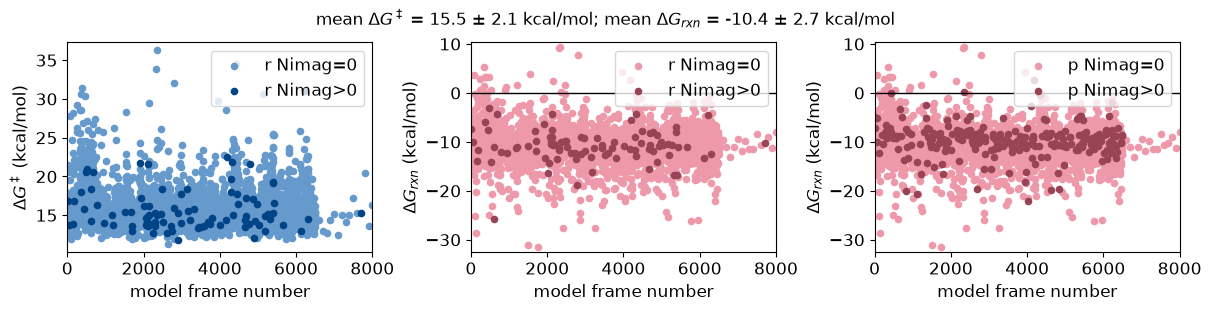

In [112]:
#df.plot.scatter(x='fnum',y='dGa',c='tot_irc_Nimag',cmap='viridis_r',ylim=(plotopts['dGa']['min']-1,plotopts['dGa']['max']+1),xlim=(plotopts['fnum']['min']-1,plotopts['fnum']['max']+1))

colours = [(tc.medium_contrast.dark_blue,tc.medium_contrast.light_blue),(tc.medium_contrast.dark_red,tc.medium_contrast.light_red)]
fig, axs = plt.subplots(nrows=1,ncols=3,figsize=(12,3),layout='constrained')

for i in [0,1,2]:
    axs[i].axhline(y=0,color='black',linewidth=1)

# first plot: dGa coloured by r Nimag
df.loc[df['r_Nimag']==0,:].plot(ax=axs[0],kind='scatter',x='fnum',y='dGa',color=tc.medium_contrast.light_blue,marker='o',label='r Nimag=0',
                                xlabel=plotopts['fnum']['longlabel'],ylabel=plotopts['dGa']['longlabel'],
                                ylim=(plotopts['dGa']['min']-1,plotopts['dGa']['max']+1),xlim=(plotopts['fnum']['min']-1,plotopts['fnum']['max']+1))
df.loc[df['r_Nimag']>0,:].plot(ax=axs[0],kind='scatter',x='fnum',y='dGa',color=tc.medium_contrast.dark_blue,marker='o', label='r Nimag>0',
                                xlabel=plotopts['fnum']['longlabel'],ylabel=plotopts['dGa']['longlabel'],
                                ylim=(plotopts['dGa']['min']-1,plotopts['dGa']['max']+1),xlim=(plotopts['fnum']['min']-1,plotopts['fnum']['max']+1))

# second plot: dGr coloured by r Nimag
df.loc[df['r_Nimag']==0,:].plot(ax=axs[1],kind='scatter',x='fnum',y='dGr',color=tc.medium_contrast.light_red,marker='o',label='r Nimag=0',
                                xlabel=plotopts['fnum']['longlabel'],ylabel=plotopts['dGr']['longlabel'],
                                ylim=(plotopts['dGr']['min']-1,plotopts['dGr']['max']+1),xlim=(plotopts['fnum']['min']-1,plotopts['fnum']['max']+1))
df.loc[df['r_Nimag']>0,:].plot(ax=axs[1],kind='scatter',x='fnum',y='dGr',color=tc.medium_contrast.dark_red,marker='o', label='r Nimag>0',
                                xlabel=plotopts['fnum']['longlabel'],ylabel=plotopts['dGr']['longlabel'],
                                ylim=(plotopts['dGr']['min']-1,plotopts['dGr']['max']+1),xlim=(plotopts['fnum']['min']-1,plotopts['fnum']['max']+1))

# third plot: dGr coloured by p Nimag
df.loc[df['p_Nimag']==0,:].plot(ax=axs[2],kind='scatter',x='fnum',y='dGr',color=tc.medium_contrast.light_red,marker='o',label='p Nimag=0',
                                xlabel=plotopts['fnum']['longlabel'],ylabel=plotopts['dGr']['longlabel'],
                                ylim=(plotopts['dGr']['min']-1,plotopts['dGr']['max']+1),xlim=(plotopts['fnum']['min']-1,plotopts['fnum']['max']+1))
df.loc[df['p_Nimag']>0,:].plot(ax=axs[2],kind='scatter',x='fnum',y='dGr',color=tc.medium_contrast.dark_red,marker='o', label='p Nimag>0',
                                xlabel=plotopts['fnum']['longlabel'],ylabel=plotopts['dGr']['longlabel'],
                                ylim=(plotopts['dGr']['min']-1,plotopts['dGr']['max']+1),xlim=(plotopts['fnum']['min']-1,plotopts['fnum']['max']+1))

fig.align_labels()
fig.suptitle(f'mean {plotopts["dGa"]["shortlabel"]} = {dGa_mean_std} kcal/mol; mean {plotopts["dGr"]["shortlabel"]} = {dGr_mean_std} kcal/mol',size=MEDIUM_SIZE)


## reaction energy vs activation energy

highlights points which have large water-only rmsds between strucs

/home/ndyonker/.local/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(


Text(0.5, 1.0, 'mean $\\Delta G ^\\ddagger$ = 15.5 ± 2.1 kcal/mol; mean $\\Delta G _{rxn}$ = -10.4 ± 2.7 kcal/mol')

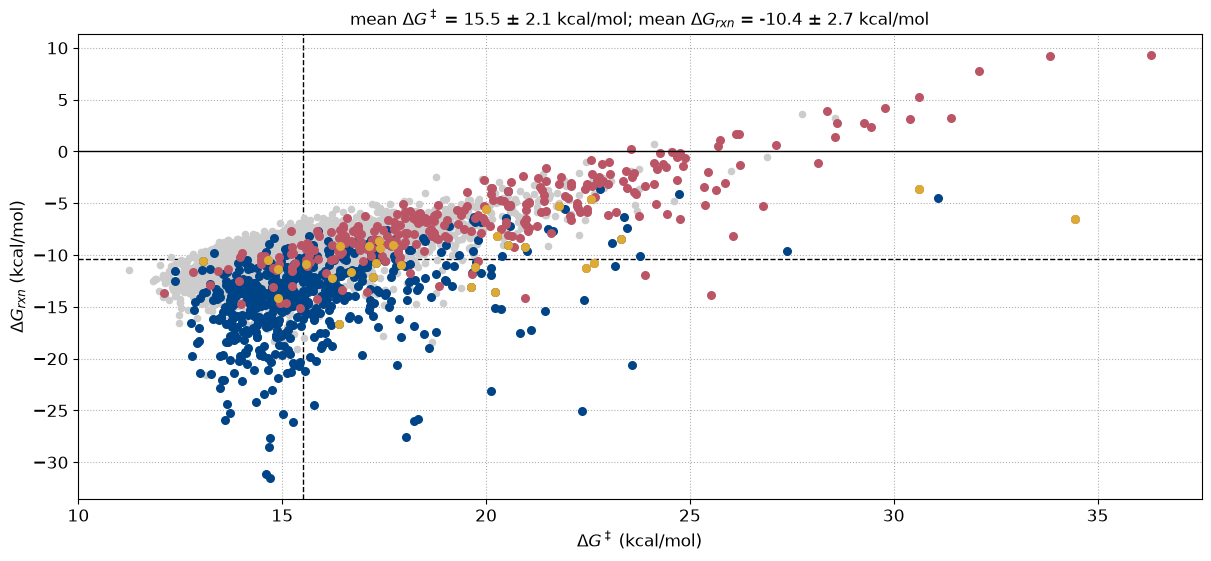

In [113]:
fig, ax = plt.subplots(figsize=(12,5.5),layout='constrained')
ax.axhline(y=0,color='black',linewidth=1)
# plot all points in grey
df.plot(ax=ax, kind='scatter',x='dGa',y='dGr', color=[0.8,0.8,0.8])
# means
ax.axhline(y=df['dGr'].mean(),color='black',linewidth=1, linestyle='--',zorder=0)
ax.axvline(x=df['dGa'].mean(),color='black',linewidth=1, linestyle='--',zorder=0)

# isolate ones where any wat rmsd is > 1
plotdf = df.loc[(df['rms_ts-p_wat']>1)|(df['rms_ts-r_wat']>1)|(df['rms_p-r_wat']>1),:]
# r more like ts than p is - product overstabilised? - colour blue
plotdf.loc[plotdf['rms_ts-r_all']<plotdf['rms_ts-p_all'],:].plot(ax=ax, kind='scatter',x='dGa',y='dGr',s=30,color=tc.high_contrast.blue)
# p more like ts than r is - reactant overstabilised? - colour red
plotdf.loc[plotdf['rms_ts-r_all']>plotdf['rms_ts-p_all'],:].plot(ax=ax, kind='scatter',x='dGa',y='dGr',s=30,color=tc.high_contrast.red)
# r and p more like each other than ts - both overstabilised? - colour yellow
plotdf.loc[(plotdf['rms_ts-r_all']>plotdf['rms_p-r_all'])&(plotdf['rms_ts-p_all']>plotdf['rms_p-r_all']),:].plot(ax=ax, kind='scatter',x='dGa',y='dGr',s=30,color=tc.high_contrast.yellow)

ax.set_ylabel(plotopts['dGr']['longlabel'])
ax.set_xlabel(plotopts['dGa']['longlabel'])
ax.grid(axis='both',which='major',linestyle=':')
ax.set_axisbelow(True)
ax.set_title(f'mean {plotopts["dGa"]["shortlabel"]} = {dGa_mean_std} kcal/mol; mean {plotopts["dGr"]["shortlabel"]} = {dGr_mean_std} kcal/mol',size=MEDIUM_SIZE)


## free energies vs number of h-bonds

In [114]:
df[['dGa','dGr']+[c for c in df.columns if 'hb' in c]]

,dGa,dGr,Nhb_ts_all,Nhb_ts_lig,Nhb_r_all,Nhb_r_lig,Nhb_p_all,Nhb_p_lig,hb_HO5_ts_fg,hb_HO5_ts_dist,hb_HO5_r_fg,hb_HO5_r_dist,hb_HO5_p_fg,hb_HO5_p_dist,hb_ts_lig-Arg63,hb_r_lig-Arg63,hb_p_lig-Arg63,hb_ts_lig-Arg7,hb_r_lig-Arg7,hb_p_lig-Arg7
frame,,,,,,,,,,,,,,,,,,,,
f00001,15.56,-11.07,19.0,11.0,19.0,11.0,19.0,11.0,78_SC_GLU/OE2,2.18,78_SC_GLU/OE2,2.21,78_SC_GLU/OE2,2.03,1hb,1hb,1hb,NaN,NaN,NaN
f00002,15.24,-11.46,20.0,10.0,20.0,10.0,20.0,10.0,78_SC_GLU/OE2,2.38,78_SC_GLU/OE2,2.25,78_SC_GLU/OE2,2.10,1hb,1hb,1hb,NaN,NaN,NaN
f00003,16.95,-12.49,24.0,11.0,22.0,10.0,23.0,10.0,78_SC_GLU/OE2,1.95,78_SC_GLU/OE2,1.88,78_SC_GLU/OE2,1.87,1hb,1hb,1hb,NaN,NaN,NaN
f00004,14.47,-9.37,18.0,9.0,18.0,9.0,17.0,9.0,78_SC_GLU/OE2,1.79,78_SC_GLU/OE2,1.81,78_SC_GLU/OE2,1.81,0hb,0hb,0hb,NaN,NaN,NaN
f00005,16.40,-8.98,22.0,10.0,22.0,10.0,22.0,10.0,78_SC_GLU/OE2,1.76,78_SC_GLU/OE2,1.78,78_SC_GLU/OE2,1.74,1hb,1hb,1hb,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
f07996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
f07997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
f07998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


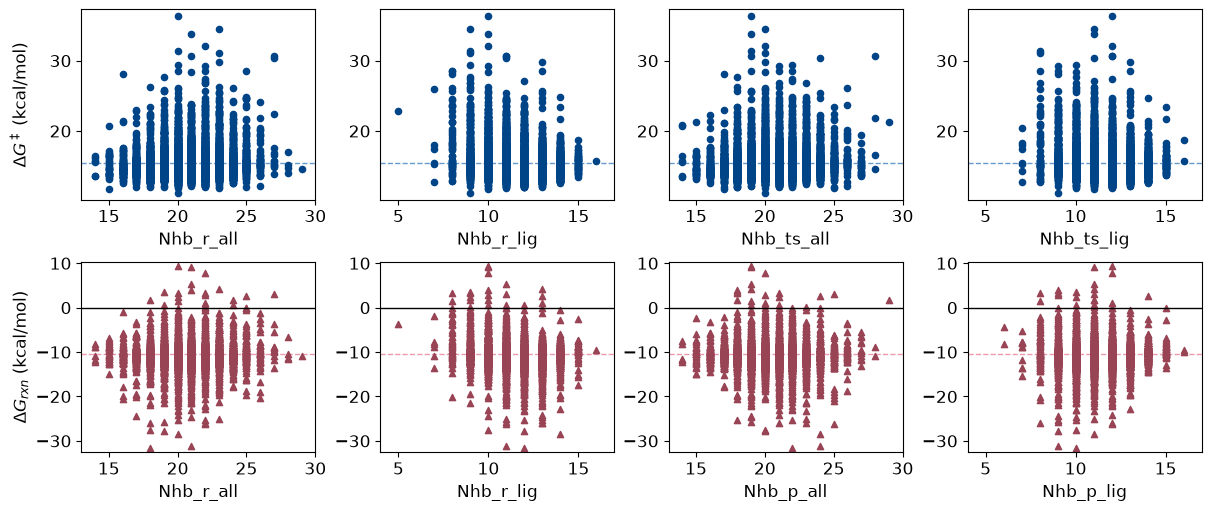

In [115]:
fig, axs = plt.subplots(nrows=2,ncols=4,figsize=(12,5),layout='constrained')
cols = [tc.medium_contrast.dark_blue,tc.medium_contrast.dark_red]
cols2 = [tc.medium_contrast.light_blue,tc.medium_contrast.light_red]
markers = ['o','^']

# first two cols - both energies against r
for i, yval in enumerate(['dGa','dGr']):
    for j, ct in enumerate(['all','lig']):
        axs[i,j].axhline(y=0,color='black',linewidth=1)
        axs[i,j].axhline(y=df[yval].mean(),color=cols2[i],linewidth=1, linestyle='--',zorder=0)
        df.plot.scatter(x=f'Nhb_r_{ct}',y=yval,ax=axs[i,j], color=cols[i], marker=markers[i], ylim=(plotopts[yval]['min']-1,plotopts[yval]['max']+1),xlim=(plotopts[f'Nhb_{ct}']['min']-1,plotopts[f'Nhb_{ct}']['max']+1))
        axs[i,j].set_ylabel(None)
        axs[i,j].set_xlabel(f'Nhb_r_{ct}')

# third and fourth cols - activation energy against ts, reaction energy against p
for i, yval in enumerate([('dGa','ts'),('dGr','p')]):
    for j, ct in enumerate(['all','lig']):
        axs[i,j+2].axhline(y=0,color='black',linewidth=1)
        axs[i,j+2].axhline(y=df[yval[0]].mean(),color=cols2[i],linewidth=1, linestyle='--',zorder=0)
        df.plot.scatter(x=f'Nhb_{yval[1]}_{ct}',y=yval[0],ax=axs[i,j+2], color=cols[i], marker=markers[i], ylim=(plotopts[yval[0]]['min']-1,plotopts[yval[0]]['max']+1),xlim=(plotopts[f'Nhb_{ct}']['min']-1,plotopts[f'Nhb_{ct}']['max']+1))
        axs[i,j+2].set_ylabel(None)
        axs[i,j+2].set_xlabel(f'Nhb_{yval[1]}_{ct}')

    
axs[0,0].set_ylabel(plotopts['dGa']['longlabel'])
axs[1,0].set_ylabel(plotopts['dGr']['longlabel'])

fig.align_labels()

## free energies vs N_hb diffs

Text(0.5, 0.98, 'mean $\\Delta G ^\\ddagger$ = 15.5 ± 2.1 kcal/mol; mean $\\Delta G _{rxn}$ = -10.4 ± 2.7 kcal/mol')

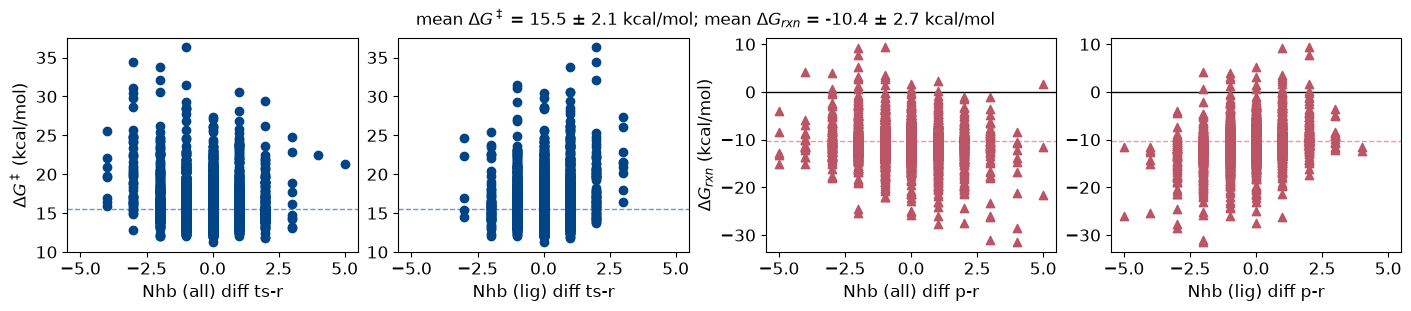

In [116]:
fig, axs = plt.subplots(nrows=1,ncols=4,figsize=(14,3),layout='constrained')

axs[0].axhline(y=df['dGa'].mean(),color=tc.medium_contrast.light_blue,linewidth=1, linestyle='--',zorder=0)
axs[0].scatter(x=df['Nhb_ts_all']-df['Nhb_r_all'], y=df['dGa'], color=tc.high_contrast.blue, marker='o')
axs[0].set_xlabel('Nhb (all) diff ts-r')

axs[1].axhline(y=df['dGa'].mean(),color=tc.medium_contrast.light_blue,linewidth=1, linestyle='--',zorder=0)
axs[1].scatter(x=df['Nhb_ts_lig']-df['Nhb_r_lig'], y=df['dGa'], color=tc.high_contrast.blue, marker='o')
axs[1].set_xlabel('Nhb (lig) diff ts-r')

axs[2].axhline(y=0,color='black',linewidth=1, zorder=0)
axs[2].axhline(y=df['dGr'].mean(),color=tc.medium_contrast.light_red,linewidth=1, linestyle='--',zorder=0)
axs[2].scatter(x=df['Nhb_p_all']-df['Nhb_r_all'], y=df['dGr'], color=tc.high_contrast.red, marker='^')
axs[2].set_xlabel('Nhb (all) diff p-r')

axs[3].axhline(y=0,color='black',linewidth=1, zorder=0)
axs[3].axhline(y=df['dGr'].mean(),color=tc.medium_contrast.light_red,linewidth=1, linestyle='--',zorder=0)
axs[3].scatter(x=df['Nhb_p_lig']-df['Nhb_r_lig'], y=df['dGr'], color=tc.high_contrast.red, marker='^')
axs[3].set_xlabel('Nhb (lig) diff p-r')

axs[0].set_ylabel(plotopts['dGa']['longlabel'])
axs[2].set_ylabel(plotopts['dGr']['longlabel'])

for i in [0,1,2,3]:
    axs[i].set_xlim(left=-5.5,right=5.5)

fig.align_labels()
fig.suptitle(f'mean {plotopts["dGa"]["shortlabel"]} = {dGa_mean_std} kcal/mol; mean {plotopts["dGr"]["shortlabel"]} = {dGr_mean_std} kcal/mol',size=MEDIUM_SIZE)


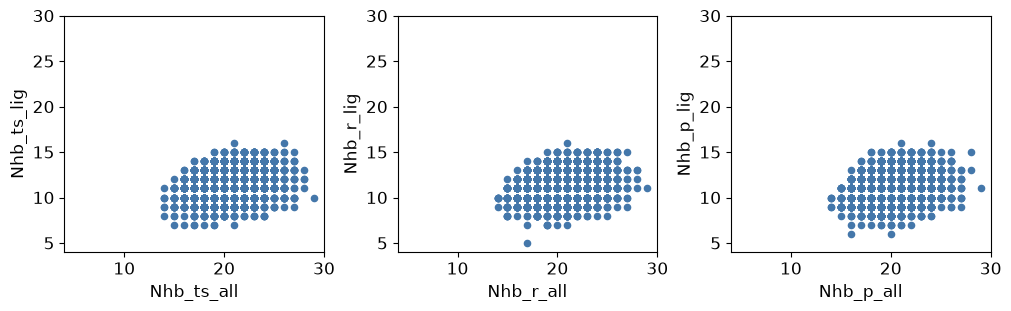

In [117]:
fig, axs = plt.subplots(nrows=1,ncols=3,figsize=(10,3),layout='constrained')

df.plot(ax=axs[0], kind='scatter', x='Nhb_ts_all', y='Nhb_ts_lig')
df.plot(ax=axs[1], kind='scatter', x='Nhb_r_all', y='Nhb_r_lig')
df.plot(ax=axs[2], kind='scatter', x='Nhb_p_all', y='Nhb_p_lig')

allmin = min([df[i].min() for i in ['Nhb_ts_lig','Nhb_r_lig','Nhb_p_lig']])
allmax = max([df[i].max() for i in ['Nhb_ts_all','Nhb_r_all','Nhb_p_all']])
for i in [0,1,2]:
    axs[i].set_xlim(left=allmin-1,right=allmax+1)
    axs[i].set_ylim(bottom=allmin-1,top=allmax+1)

fig.align_labels()


## free energies grouped by what ligand hydroxide is pointing to

this looks janky rn at least for A/C* bc there's no models without Glu yet. maybe won't be useful for this but can be repurposed to look at Arg63 once you're collecting that data

Text(0.5, 0.98, 'mean $\\Delta G ^\\ddagger$ = 15.5 ± 2.1 kcal/mol; mean $\\Delta G _{rxn}$ = -10.4 ± 2.7 kcal/mol')

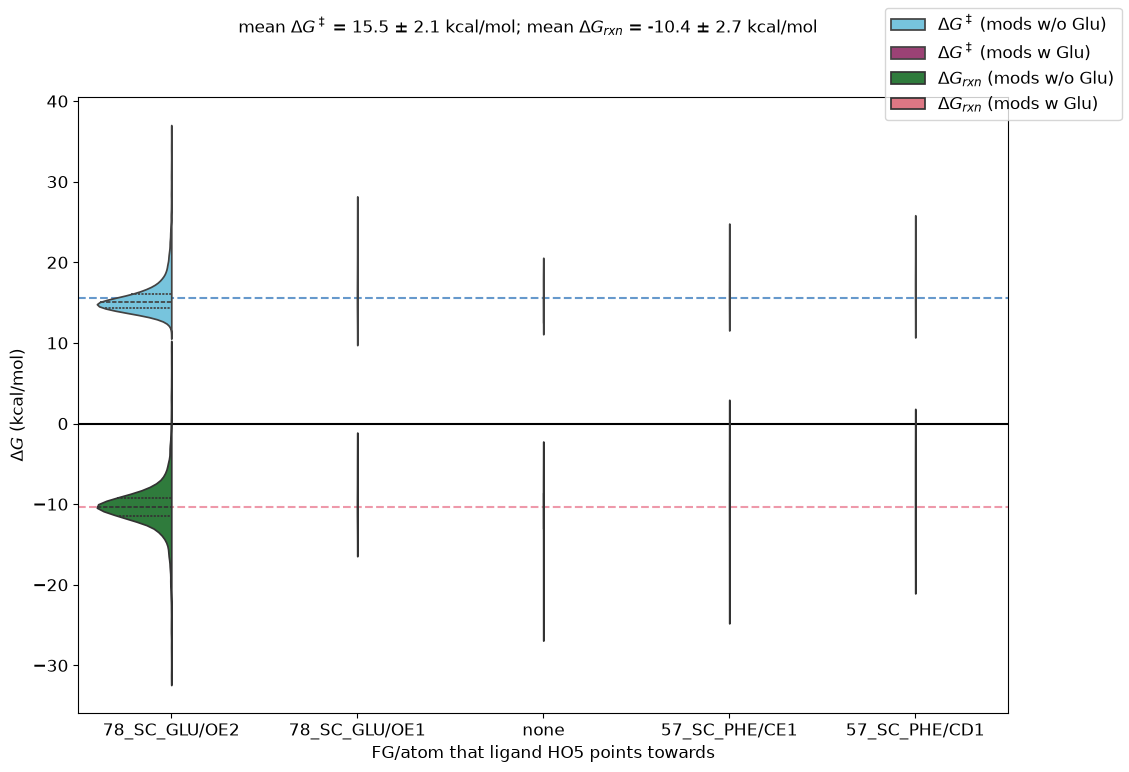

In [118]:
glu78col = [c for c in fg_df.columns if 'SC_GLU' in c][0]   # there is only one glu SC so this works fine. if looking at Arg63, need to make sure your code is selecting right Arg!
plotdf = pd.concat([df,fg_df[glu78col]],axis=1)
fig, ax = plt.subplots(figsize=(12,8))
ax.axhline(y=0, color='black', zorder=0)
# not doing common norm so you can actually see all plots
sns.violinplot(ax=ax, data=plotdf, x='hb_HO5_ts_fg', y='dGa', hue=glu78col, hue_order=[1,0], palette=[tc.bright.cyan,tc.bright.purple], split=True, inner='quart', density_norm='count', common_norm=True)
ax.axhline(y=df['dGa'].mean(), color=tc.medium_contrast.light_blue, linestyle='--', zorder=0)
sns.violinplot(ax=ax, data=plotdf, x='hb_HO5_ts_fg', y='dGr', hue=glu78col, hue_order=[1,0], palette=[tc.bright.green,tc.bright.red], split=True, inner='quart', density_norm='count', common_norm=True)
ax.axhline(y=df['dGr'].mean(), color=tc.medium_contrast.light_red, linestyle='--', zorder=0)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles=handles, labels=[r'$\Delta G ^\ddagger$ (mods w/o Glu)', r'$\Delta G ^\ddagger$ (mods w Glu)',r'$\Delta G _{rxn}$ (mods w/o Glu)', r'$\Delta G _{rxn}$ (mods w Glu)'], 
            title=None, ncols=1, loc='outside upper right')
ax.legend().set_visible(False)

ax.set_ylabel(r'$\Delta G$ (kcal/mol)')
ax.set_xlabel('FG/atom that ligand HO5 points towards')
fig.suptitle(f'mean {plotopts["dGa"]["shortlabel"]} = {dGa_mean_std} kcal/mol; mean {plotopts["dGr"]["shortlabel"]} = {dGr_mean_std} kcal/mol',size=MEDIUM_SIZE)



## free energies vs Arg63 h-bonds

Text(0.5, 0.98, 'mean $\\Delta G ^\\ddagger$ = 15.5 ± 2.1 kcal/mol; mean $\\Delta G _{rxn}$ = -10.4 ± 2.7 kcal/mol')

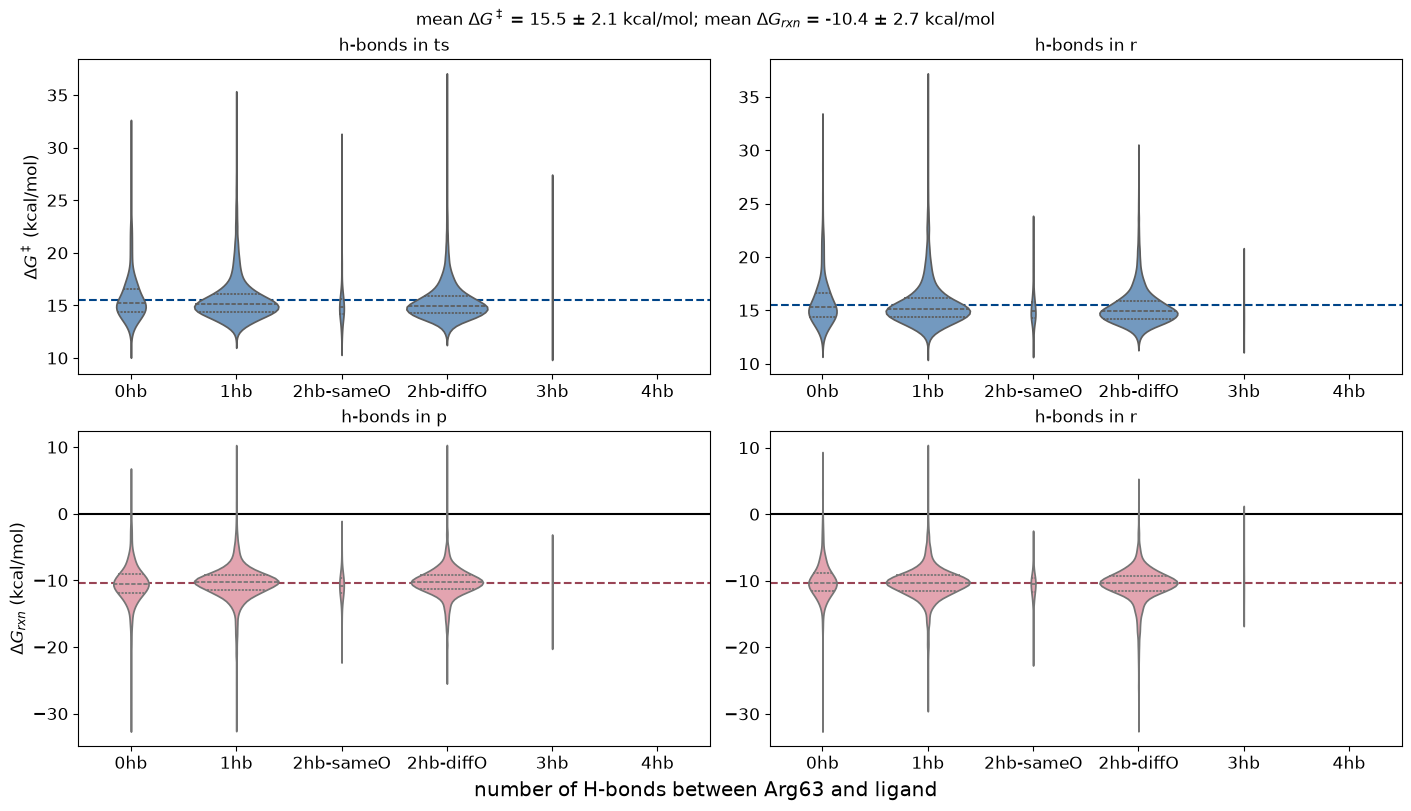

In [119]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14,8), layout='constrained')

# top left: activation energies vs ts hbs
sns.violinplot(ax=axs[0,0], data=df, x='hb_ts_lig-Arg63', y='dGa', order=['0hb','1hb','2hb-sameO','2hb-diffO','3hb','4hb'],
            color=tc.medium_contrast.light_blue, inner='quart', density_norm='count', common_norm=True)
axs[0,0].axhline(y=df['dGa'].mean(), color=tc.medium_contrast.dark_blue, linestyle='--', zorder=0)
axs[0,0].set_ylabel(plotopts['dGa']['longlabel'])
axs[0,0].set_title('h-bonds in ts')

# top right plot: activation energies vs r hbs
sns.violinplot(ax=axs[0,1], data=df, x='hb_r_lig-Arg63', y='dGa', order=['0hb','1hb','2hb-sameO','2hb-diffO','3hb','4hb'],
            color=tc.medium_contrast.light_blue, inner='quart', density_norm='count', common_norm=True)
axs[0,1].axhline(y=df['dGa'].mean(), color=tc.medium_contrast.dark_blue, linestyle='--', zorder=0)
axs[0,1].set_ylabel(None)
axs[0,1].set_title('h-bonds in r')

# bottom left plot: reaction energies vs p hbs
axs[1,0].axhline(y=0, color='black', zorder=0)
sns.violinplot(ax=axs[1,0], data=plotdf, x='hb_p_lig-Arg63', y='dGr', order=['0hb','1hb','2hb-sameO','2hb-diffO','3hb','4hb'],
            color=tc.medium_contrast.light_red, inner='quart', density_norm='count', common_norm=True)
axs[1,0].axhline(y=df['dGr'].mean(), color=tc.medium_contrast.dark_red, linestyle='--', zorder=0)
axs[1,0].set_ylabel(plotopts['dGr']['longlabel'])
axs[1,0].set_title('h-bonds in p')

# bottom left plot: reaction energies vs r hbs
axs[1,1].axhline(y=0, color='black', zorder=0)
sns.violinplot(ax=axs[1,1], data=plotdf, x='hb_r_lig-Arg63', y='dGr', order=['0hb','1hb','2hb-sameO','2hb-diffO','3hb','4hb'],
            color=tc.medium_contrast.light_red, inner='quart', density_norm='count', common_norm=True)
axs[1,1].axhline(y=df['dGr'].mean(), color=tc.medium_contrast.dark_red, linestyle='--', zorder=0)
axs[1,1].set_ylabel(None)
axs[1,1].set_title('h-bonds in r')

axs[0,0].set_xlabel(None)
axs[0,1].set_xlabel(None)
axs[1,0].set_xlabel(None)
axs[1,1].set_xlabel(None)
fig.supxlabel('number of H-bonds between Arg63 and ligand')
fig.suptitle(f'mean {plotopts["dGa"]["shortlabel"]} = {dGa_mean_std} kcal/mol; mean {plotopts["dGr"]["shortlabel"]} = {dGr_mean_std} kcal/mol',size=MEDIUM_SIZE)


In [120]:
# dGa stats by presence of arg63/ts arg63-lig h-bonds/r arg63-lig h-bonds
df_with_arg63 = pd.concat([df[['dGa','hb_ts_lig-Arg63','hb_r_lig-Arg63']],fg_df['63_SC_ARG']],axis='columns')
print(df_with_arg63.groupby(by=['63_SC_ARG','hb_ts_lig-Arg63','hb_r_lig-Arg63']).agg(['count','median','mean',std,'min','max']).round(1))
# print overall dGa mean/std for comparison
print(f'                                    overall mean dGa = {dGa_mean_std} kcal/mol\n')


# then dGr stats by presence of arg63/p arg63-lig h-bonds/r arg63-lig h-bonds
df_with_arg63 = pd.concat([df[['dGr','hb_p_lig-Arg63','hb_r_lig-Arg63']],fg_df['63_SC_ARG']],axis='columns')
print(df_with_arg63.groupby(by=['63_SC_ARG','hb_p_lig-Arg63','hb_r_lig-Arg63']).agg(['count','median','mean',std,'min','max']).round(1))
# overall dGr mean/std for comparison
print(f'                                  overall mean dGr = {dGr_mean_std} kcal/mol')

                                           dGa                              
                                         count median  mean  std   min   max
63_SC_ARG hb_ts_lig-Arg63 hb_r_lig-Arg63                                    
0         0hb             0hb              256   15.9  16.9  3.2  12.4  31.4
1         0hb             0hb              609   15.0  15.4  1.8  12.0  23.0
                          1hb               58   15.3  15.7  2.2  11.2  22.9
                          2hb-diffO          1   14.5  14.5  0.0  14.5  14.5
          1hb             0hb               31   18.3  19.1  4.8  13.3  32.1
                          1hb             2527   15.1  15.5  2.1  11.9  34.4
                          2hb-diffO         67   15.0  15.8  2.7  12.9  26.2
                          2hb-sameO         16   15.3  15.6  1.0  14.3  17.8
                          3hb                1   17.3  17.3  0.0  17.3  17.3
          2hb-diffO       0hb                4   19.4  19.3  1.6  16.9  21.4

In [121]:
# find models where arginine 63 is present but doesn't have hbonds with ligand
showcols = ['dGa','dGr','hb_ts_lig-Arg63','hb_r_lig-Arg63','hb_p_lig-Arg63']
df.loc[(fg_df['63_SC_ARG']==1)&(df['hb_r_lig-Arg63']=='0hb'),showcols]

,dGa,dGr,hb_ts_lig-Arg63,hb_r_lig-Arg63,hb_p_lig-Arg63
frame,,,,,
f00004,14.47,-9.37,0hb,0hb,0hb
f00011,15.58,-9.76,0hb,0hb,0hb
f00014,13.69,-10.49,0hb,0hb,0hb
f00017,17.71,-9.82,0hb,0hb,0hb
f00024,14.86,-12.51,0hb,0hb,0hb
...,...,...,...,...,...
f06448,14.31,-11.19,0hb,0hb,0hb
f06461,14.41,-10.71,0hb,0hb,0hb
f06462,14.20,-11.48,0hb,0hb,0hb


### more arg h-bond analysis

not related to energies anymore but keeping here with the other stuff so it's easier to find

In [122]:
fdir

[]

In [123]:
### READ IN ORIGINAL PROBE DATA FOR COMPARISON ###
# check which active site's data to read in
if 'QM-A' in path or fdir == ['A128-every-100th'] or fdir == ['A128-every-100th-1pct-filter']: 
    MDpath = '/project/dwappett/old_MD_stuff/md/analysis_groupmeeting/MERGED-BATCH-A128-PROBE-WITH-WAT'
elif 'QM-B' in path or fdir == ['B256-every-100th']or fdir == ['B256-every-100th-1pct-filter']:
    MDpath = '/project/dwappett/old_MD_stuff/md/analysis_groupmeeting/MERGED-BATCH-B256-PROBE-WITH-WAT'
elif 'QM-C' in path or fdir == ['C384-every-100th']or fdir == ['C384-every-100th-1pct-filter']:
    MDpath = '/project/dwappett/old_MD_stuff/md/analysis_groupmeeting/MERGED-BATCH-C384-PROBE-WITH-WAT'

with open(f'{MDpath}/batch_rawdf.pkl','rb') as fp:
    original_probe_hb_counts = pickle.load(fp)
wats = [res for res in original_probe_hb_counts.index.levels[0].values if res.endswith('WAT')]
original_probe_hb_counts = original_probe_hb_counts.drop(index=wats,level=0)
original_probe_hb_counts = original_probe_hb_counts['p_hb']

FG_equivalents = {}
prot = original_probe_hb_counts.index.get_level_values(0).unique()
for i in prot:
    ch, idx, res = i.split(':')
    idx = int(idx) % 128
    FG_equivalents[i] = f'{idx}_{res}'
newindex = [(FG_equivalents[i[0]],i[1]) for i in original_probe_hb_counts.index.values]
original_probe_hb_counts.index = pd.MultiIndex.from_tuples(newindex)

original_probe_hb_counts
original_probe_hb_counts = original_probe_hb_counts.unstack(level=0)
original_probe_hb_counts.index = [f'f{i.split(".")[-1]}' for i in original_probe_hb_counts.index]
original_probe_hb_counts

,108_TYR_SC,115_LEU_SC,115_MC,117_PRO_SC,57_MC,57_PHE_SC,58_MC,59_ALA_SC,59_MC,60_LYS_SC,63_ARG_SC,73_MC,73_VAL_SC,74_MC,74_THR_SC,75_CYS_SC,78_GLU_SC,7_ARG_SC,90_ARG_SC,9_ALA_SC
f00001,67.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,20.0,0.0,0.0,76.0,75.0,0.0,NaN
f00002,61.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,0.0,45.0,0.0,NaN,20.0,0.0,2.0,73.0,73.0,12.0,NaN
f00003,72.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,0.0,49.0,0.0,NaN,17.0,0.0,67.0,70.0,108.0,0.0,NaN
f00004,79.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.0,57.0,0.0,NaN,1.0,0.0,65.0,72.0,101.0,17.0,NaN
f00005,77.0,0.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,60.0,0.0,0.0,20.0,0.0,8.0,74.0,127.0,53.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
f19996,77.0,0.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,127.0,0.0,0.0,48.0,0.0,6.0,75.0,139.0,30.0,NaN
f19997,66.0,0.0,NaN,NaN,NaN,0.0,NaN,0.0,0.0,NaN,121.0,0.0,0.0,28.0,0.0,53.0,79.0,129.0,75.0,NaN
f19998,0.0,0.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN
f19999,0.0,0.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN


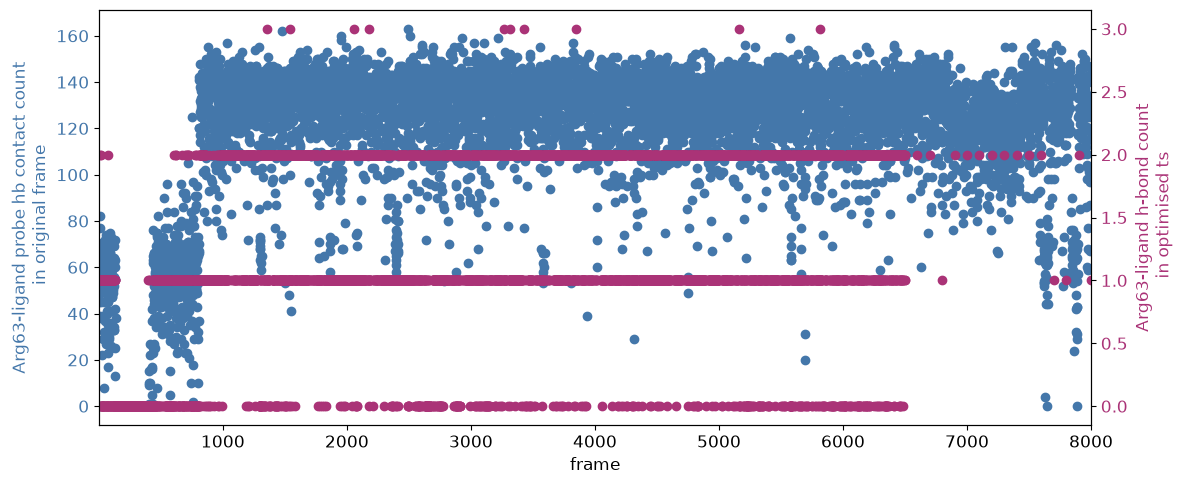

In [124]:
# get just number of lig-arg hbonds, not differentiating between the two 2-hb cases
Nhb = []
for i in df.index:
    try:
        Nhb.append(int(df.loc[i,'hb_ts_lig-Arg63'][0]))
    except:
        Nhb.append(np.nan)

# plot original probe hb contact counts and number of hbs in opt ts with separate y axes
fig, ax1 = plt.subplots(figsize=(12,5))
color = tc.bright.blue
ax1.set_xlabel('frame')
ax1.set_ylabel('Arg63-ligand probe hb contact count\n in original frame', color=color)
ax1.scatter(x=df['fnum'], y=original_probe_hb_counts.loc[df.index,'63_ARG_SC'], color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlim(left=plotopts['fnum']['min'],right=plotopts['fnum']['max'])

ax2 = ax1.twinx()
color = tc.bright.purple
ax2.set_xlabel('frame')
ax2.set_ylabel('Arg63-ligand h-bond count\n in optimised ts', color=color)
ax2.scatter(x=df['fnum'], y=Nhb, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()

# Compile outliers from all tests

## extract rows of data frame

In [125]:
outlier_table = df.loc[compile_outliers.keys(),:].copy(deep=True)
outlier_table.insert(loc=0,column='checks_failed',value=[compile_outliers[i] for i in compile_outliers.keys()])
outlier_table.sort_index(axis=0,inplace=True)
outlier_table
outlier_table.to_csv('outlier_table.csv', index = 'frame')

## excluding these from set?

if you determine exclusion thresholds for any other quantities, there are a few ways you can exclude stuff from the main set:
- if we want them fully excluded from next data collection: use list of models from outlier_checks/outlier_table to put an `overwrite-check.txt` file containing the word "exclude" in those directories. but at least right now, that has to be in tsopt or one of the irc directories even if the problem identified is in the initialopt/tsconstrained, otherwise check_cm_jobs/collect_cm_results will still see all the important (tsopt/irc1/irc2) jobs as done/collect-able. 
- other option that means you can still see what's being filtered out: add code block here after all checks that saves list of all models that have failed the checks to a file in your QM dir, and then have code block at start of the paper notebook (which does the proper combined analysis) that reads that list and removes those rows from the QMdata dfs (or cancels out their values if removing rows/having non-matching indexes breaks all the plots lol)

# extra: details of everyone's active sites

sticking this here like an appendix in case anyone needs it but it's probably not necessary for this notebook


|             | ligand | active site   | frames      | model type | parent directory for project                        |
|-------------|--------|---------------|-------------|------------|-----------------------------------------------------|
| **Dr D.**   | A:128  | A/C interface | all         | individual | /project/ndyonker/chem/cm-MD-processing/MD-QM/QM-A  |
| **Pedro**   | B:256  | B/A interface | all         | individual | /project/pssntngr/chem/chorismate_mutase/QM-B/      |
| **Haritha** | C:384  | C/B interface | all         | individual | /project/hksasi/chem/chorismate_mutase/QM-C/        |
| **Domi**    | all    | all           | every 100th | batch      | /project/dwappett/chorismate_mutase/QM-batch-models |
